# Phase 1 - Goal

The goal of this project is to build a machine learning model that predicts NBA Draft outcome groups using pre-draft player information.

Instead of predicting the exact draft pick number, the task is formulated as a supervised multiclass classification problem. Exact draft pick prediction is very noisy because player selection depends not only on player quality, but also on team needs, draft class strength, injuries and strategic decisions by NBA teams.

Therefore, the target variable will be defined as broader draft outcome groups:

- top_5: picks 1-5

- picks_6_14: picks 6-14

- picks_15_30: picks 15-30

- second_round: picks 31-60 

- undrafted: players who entered the dataset but were not drafted

Players from the 2026 draft class will be treated as a prediction pool. 
Their draft outcome is unknown at the time of modeling and will not be used for model training.

# Phase 2 - Data collection

The project dataset combines several types of pre-draft information:

NBA Draft History: draft year, overall pick, draft team, and player organization
NBA Draft Combine: physical measurements and athletic testing results
College basketball data: box-score statistics and advanced college metrics
NBA API + RealGM manual improvement: birth dates and draft age

The project dataset was collected from multiple sources, using multiple APIs, and then manually refined. As a result, the data is quite heterogeneous  which will be examined in the third stage. 

The reason is the lack of the data necessary for the project in a single file.

In [2]:
# Phase 2 - Data loading (pre-constructed but not cleaned dataset) and presentation

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

DATA_PATH = Path("data/final/nba_draft_full_clean_project_FINAL_2000_2026.csv")

df = pd.read_csv(DATA_PATH)

print("Players:")
print(df.shape[0])

print("Attributes:")
print(df.shape[1])

print("Columns:")
print(df.columns)

Players:
2347
Attributes:
51
Columns:
Index(['name', 'draft_year', 'overall_pick', 'position', 'organization',
       'organization_type', 'draft_team_abbreviation', 'height_wo_shoes_in',
       'height_w_shoes_in', 'weight_lbs', 'wingspan_in', 'standing_reach_in',
       'body_fat_pct', 'hand_length_in', 'hand_width_in',
       'standing_vertical_leap_in', 'max_vertical_leap_in',
       'lane_agility_time_sec', 'modified_lane_agility_time_sec',
       'three_quarter_sprint_sec', 'bench_press_reps', 'ncaa_conf', 'ncaa_pos',
       'ncaa_exp', 'ncaa_height', 'ncaa_games', 'ncaa_mpg', 'ncaa_ppg',
       'ncaa_fg_pct', 'ncaa_two_pct', 'ncaa_three_pct', 'ncaa_ft_pct',
       'ncaa_oreb', 'ncaa_dreb', 'ncaa_rpg', 'ncaa_apg', 'ncaa_ast_to',
       'ncaa_spg', 'ncaa_bpg', 'ncaa_tpg', 'ncaa_ortg', 'ncaa_adj_oe',
       'ncaa_drtg', 'ncaa_porpag', 'ncaa_dporpag', 'ncaa_bpm', 'ncaa_obpm',
       'ncaa_dbpm', 'ncaa_usage', 'birth_date', 'draft_age'],
      dtype='object')


Brief description of selected attributes:

- name - the player's name, a unique ID
- draft_year - the year of the draft selection. Different “draft classes” (players entered into and selected in the draft in different years) can vary significantly in terms of strength
- overall_pick - draft pick number, a source for predictor variable (before dividing into classes)
- position - playing position, categorical variable
- organization and organization_type - the team the person played for before being drafted, a university, or a European/Asian professional team
- height_wo_shoes_in, height_w_shoes_in, weight_lbs etc - players’ physical measurements prior to the draft
- ncaa_conf - the conference in which the player’s college team plays. These can vary significantly in strength, and players from stronger conferences are preferred by NBA teams. 
- ncaa_mpg, ncaa_ppg, ncaa_fg_pct, etc. - players' official game statistics from their time in the NCAA (college basketball)
- draft_age - age as of draft day 

# Phase 3 - Exploratory Data Analysis

The goal of this stage is to understand whether the collected data is suitable for the prediction task defined in Phase 1, to identify potential data quality issues, and to decide what transformations will be necessary in Phase 4.

The EDA, except the usual checks of missing values and attributes distributions, will focus on several domain-specific questions:

* Are numerical variables comparable across draft years?

  Since each draft selection is made from a limited pool of players, it's theoretically possible for two players with identical stats to be selected at different picks because one draft class is stronger than the other. For example, averaging 20 points per game might be a top-performing player in 2015, but not even a top-five finish in 2016. This effect should be tested and, if necessary, transformed from numerical values to deviations from the average within a single draft class, so that the data reflects how much a player is stronger or weaker than others in the same year, rather than absolute values.

* Can draft picks be predicted as a continuous variable?

  As noted above, predicting a player's exact draft position is likely extremely difficult due to the large amount of noise in the data. Therefore, it's better to break the predicted variable into groups and reduce the task to classification. At this stage, it's important to ensure that this is the correct strategy.

### EDA Step 1: Main numerical statistics 

In [3]:
combine_cols = [
    "height_wo_shoes_in", "height_w_shoes_in", "weight_lbs",
    "wingspan_in", "standing_reach_in", "body_fat_pct",
    "hand_length_in", "hand_width_in",
    "standing_vertical_leap_in", "max_vertical_leap_in",
    "lane_agility_time_sec", "modified_lane_agility_time_sec",
    "three_quarter_sprint_sec", "bench_press_reps"
]

ncaa_cols = [
    "ncaa_games", "ncaa_mpg", "ncaa_ppg", "ncaa_fg_pct",
    "ncaa_two_pct", "ncaa_three_pct", "ncaa_ft_pct",
    "ncaa_oreb", "ncaa_dreb", "ncaa_rpg", "ncaa_apg",
    "ncaa_ast_to", "ncaa_spg", "ncaa_bpg", "ncaa_tpg",
    "ncaa_ortg", "ncaa_adj_oe", "ncaa_drtg",
    "ncaa_porpag", "ncaa_dporpag", "ncaa_bpm",
    "ncaa_obpm", "ncaa_dbpm", "ncaa_usage"
]

df[combine_cols].describe()

,height_wo_shoes_in,height_w_shoes_in,weight_lbs,wingspan_in,standing_reach_in,body_fat_pct,hand_length_in,hand_width_in,standing_vertical_leap_in,max_vertical_leap_in,lane_agility_time_sec,modified_lane_agility_time_sec,three_quarter_sprint_sec,bench_press_reps
count,1812.000000,1205.000000,1810.000000,1812.000000,1811.000000,1276.000000,1076.000000,1076.000000,1617.000000,1617.000000,1611.000000,729.000000,1611.000000,1095.000000
mean,77.681816,78.788963,215.140575,82.377787,103.544809,7.529169,8.722500,9.433494,29.281849,34.650897,11.378734,3.057545,3.272011,10.314155
std,3.367784,3.301766,25.959277,4.000778,4.882938,2.933166,0.474671,0.691882,3.094291,3.685936,0.580499,0.206090,0.134130,5.541429
min,67.750000,69.000000,149.200000,70.000000,88.500000,2.600000,7.500000,7.000000,19.500000,21.000000,9.650000,2.220000,2.870000,0.000000
25%,75.500000,76.500000,196.200000,79.750000,100.000000,5.437500,8.500000,9.000000,27.000000,32.000000,10.970000,2.930000,3.180000,6.000000
50%,78.000000,79.000000,213.200000,82.500000,104.000000,6.700000,8.750000,9.500000,29.000000,34.500000,11.300000,3.060000,3.260000,10.000000
75%,80.250000,81.250000,232.800000,85.250000,107.000000,8.800000,9.000000,10.000000,31.500000,37.000000,11.700000,3.190000,3.350000,14.000000
max,89.250000,91.000000,334.000000,98.250000,122.500000,23.100000,10.500000,12.000000,41.500000,48.000000,14.450000,3.760000,3.810000,27.000000


In [4]:
df[ncaa_cols].describe()

,ncaa_games,ncaa_mpg,ncaa_ppg,ncaa_fg_pct,ncaa_two_pct,ncaa_three_pct,ncaa_ft_pct,ncaa_oreb,ncaa_dreb,ncaa_rpg,...,ncaa_tpg,ncaa_ortg,ncaa_adj_oe,ncaa_drtg,ncaa_porpag,ncaa_dporpag,ncaa_bpm,ncaa_obpm,ncaa_dbpm,ncaa_usage
count,1849.000000,1640.000000,1848.000000,1641.000000,1849.000000,1779.000000,1848.000000,1249.000000,1249.000000,1848.000000,...,1640.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000
mean,32.310438,30.921828,15.248507,0.500362,0.527073,0.322563,0.735824,1.629642,4.458220,6.137468,...,2.217872,113.086960,103.080666,112.523894,24.881407,3.776875,7.049758,4.724414,2.325344,24.365280
std,5.061195,4.592375,4.105344,0.075379,0.063736,0.139683,0.096594,0.980029,1.562683,2.320833,...,0.712959,8.622318,45.739039,40.918037,46.949524,0.685095,2.985680,2.397349,1.733651,4.198213
min,1.000000,1.500000,0.000000,0.000000,0.000000,0.000000,0.295000,0.047600,0.944400,1.000000,...,0.000000,71.800000,1.200000,13.426700,-0.789467,1.118090,-11.898900,-8.992100,-2.911120,12.200000
25%,31.000000,28.808100,12.529000,0.448071,0.486000,0.294000,0.679750,0.800000,3.259300,4.300000,...,1.705100,107.525000,110.249000,93.053275,3.311460,3.367195,5.165110,3.171635,1.154728,21.500000
50%,33.000000,31.878700,15.333300,0.486000,0.522000,0.353000,0.749500,1.454500,4.228600,5.862350,...,2.184650,112.900000,120.376500,97.738250,4.342315,3.810575,7.030400,4.627160,2.161920,24.400000
75%,35.000000,34.100000,17.855150,0.544000,0.565000,0.394000,0.805000,2.303000,5.472200,7.669375,...,2.656200,118.700000,128.582000,103.210750,5.672103,4.220862,8.944008,6.236858,3.329787,27.200000
max,41.000000,40.000000,29.305600,0.820339,0.800000,1.000000,1.000000,5.750000,10.542900,14.400000,...,5.218800,143.100000,152.849000,292.956000,160.039000,5.800530,18.672600,12.801600,11.530500,38.400000


The values seem reasonable, based on my understanding of the domain. No significant outliers were found; some statistical anomalies, such as a 100% rating in ncaa_three_pct (three-point field goal percentage), are likely due to the player’s low number of attempts, which simply indicates that individual attributes are unlikely to be significant indicators and should be considered in conjunction with one another. 

It should be noted that all measurements from the Draft Combine are given in inches. 

The “count” row shows that most columns are poorly filled. We need to check the distribution of missing values. 

### EDA Step 2: Missing values overview

In [5]:
missing_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "non_missing": df.notna().sum().values,
    "missing_pct": (df.isna().mean().values * 100).round(2),
})

missing_summary = missing_summary.sort_values(
    by=["missing_pct", "column"],
    ascending=[False, True]
)

missing_summary

,column,dtype,missing,non_missing,missing_pct
18,modified_lane_agility_time_sec,float64,1618,729,68.94
13,hand_length_in,float64,1271,1076,54.15
14,hand_width_in,float64,1271,1076,54.15
20,bench_press_reps,float64,1252,1095,53.34
22,ncaa_pos,object,1234,1113,52.58
8,height_w_shoes_in,float64,1142,1205,48.66
36,ncaa_ast_to,float64,1098,1249,46.78
33,ncaa_dreb,float64,1098,1249,46.78
32,ncaa_oreb,float64,1098,1249,46.78
41,ncaa_adj_oe,float64,1097,1250,46.74


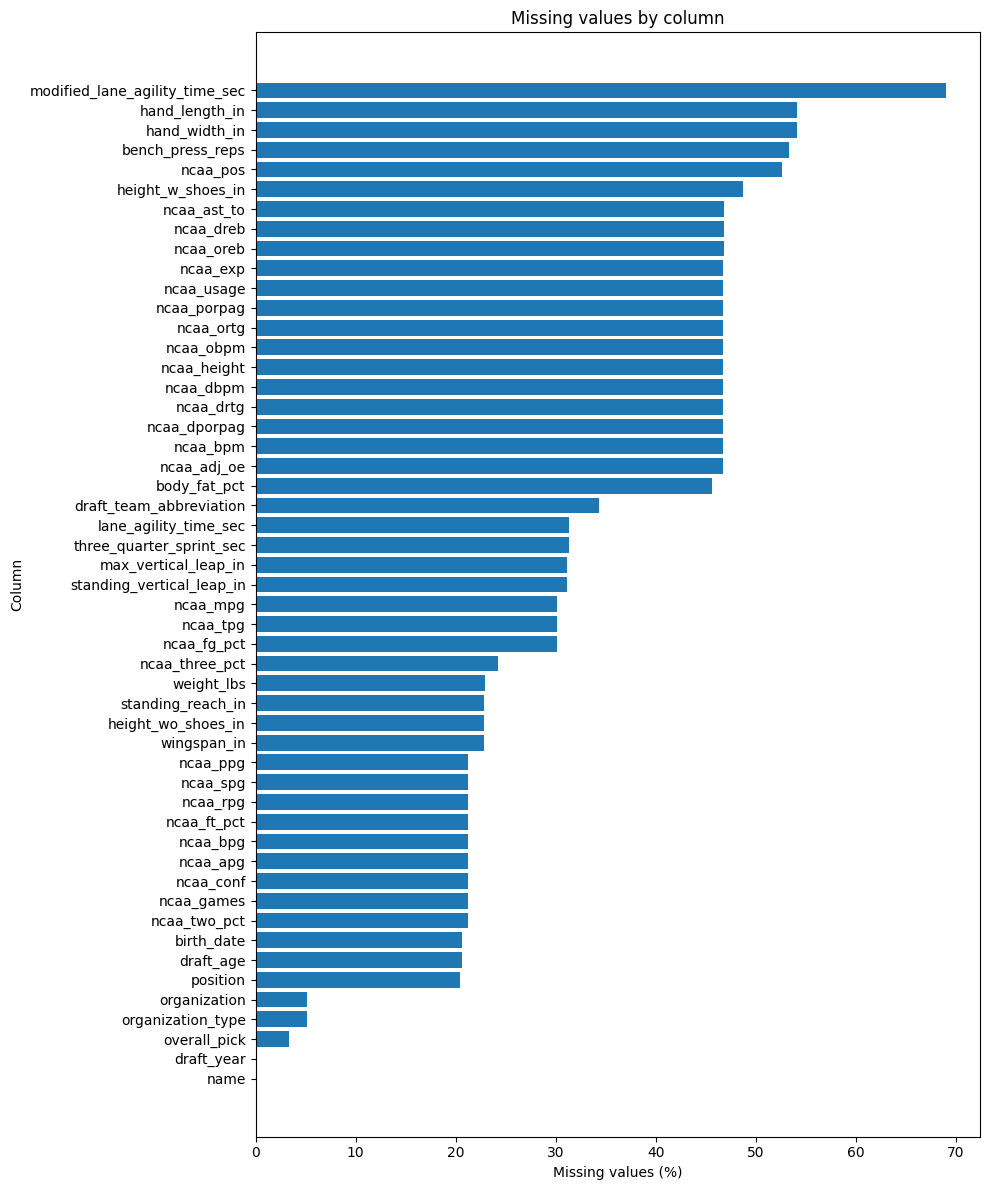

In [6]:
missing_plot_data = missing_summary.sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(missing_plot_data["column"], missing_plot_data["missing_pct"])
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

There are quite a few missing values across various categories. Some of these are easily explained; for example, the missing `overall_pick` values correspond to players from 2026, or, as is obvious, international players lack NCAA data. Let’s try to examine the distribution of particular missing values (like Combine-related or NCAA-related) across groups and draft classes. 

We may also consider completely removing certain attributes in the future if they turn out not to be very important and there are many missing values, for example, modified_lane_agility_time_sec

In [7]:
diagnostic = pd.DataFrame({
    "draft_year": df["draft_year"],
    "organization_type": df["organization_type"].fillna("Missing organization type"),
    "has_any_combine": df[combine_cols].notna().any(axis=1),
    "has_any_ncaa": df[ncaa_cols].notna().any(axis=1)
})

availability_by_org_type = (
    diagnostic
    .groupby("organization_type")
    .agg(
        rows=("draft_year", "count"),
        pct_with_any_combine=("has_any_combine", "mean"),
        pct_with_any_ncaa=("has_any_ncaa", "mean"),
    )
    .reset_index()
)

availability_by_org_type

,organization_type,rows,pct_with_any_combine,pct_with_any_ncaa
0,College/University,1875,0.856000,0.986133
1,High School,35,0.542857,0.000000
2,Missing organization type,121,0.975207,0.000000
3,Other Team/Club,316,0.234177,0.000000


We can see that, as expected, players who did not play for a college team prior to the draft do not have any NCAA-related columns. However, for players who did play in college, there are almost no missing values here; in fact, such players make up the majority. Consequently, in the future, we may consider retaining only players who played in college, as we lack sufficient data for the rest. Furthermore, players coming from high school and international players (Other Team/Club) also lack more than half of the data from the Draft Combine. The category of players with a missing organization value, in the absence of college data, has very good data coverage from the Combine, so it may make sense to keep them. 

In [8]:
availability_by_year = (
    diagnostic
    .groupby("draft_year")
    .agg(
        rows=("draft_year", "count"),
        pct_with_any_combine=("has_any_combine", "mean"),
        pct_with_any_ncaa=("has_any_ncaa", "mean"),
    )
    .reset_index()
)

availability_by_year.sort_values("pct_with_any_combine", ascending=False)

,draft_year,rows,pct_with_any_combine,pct_with_any_ncaa
24,2024,84,0.988095,0.785714
26,2026,78,0.961538,0.948718
25,2025,86,0.918605,0.790698
12,2012,71,0.859155,0.873239
1,2001,96,0.812500,0.770833
18,2018,85,0.811765,0.847059
13,2013,78,0.807692,0.782051
23,2023,83,0.807229,0.831325
2,2002,102,0.803922,0.745098
19,2019,88,0.795455,0.829545


We can see that, although older draft classes tend to have more missing values, the difference is not dramatic, which means that the time interval chosen for data collection is optimal. 

Interestingly, the high number of missing measurements from the 2020 Draft Combine is likely due to the COVID-19 pandemic. 

### EDA Step 3: Visual inspection of numerical variable distribution and errors identification

Now that we’ve decided which observations we’ll likely keep, let’s take a closer look at which attributes might be useful to us by examining their distributions. 

In [9]:
def plot_histograms(columns, title, bins=30, n_cols=4):
    valid_columns = [col for col in columns if col in df.columns]
    n_plots = len(valid_columns)
    n_rows = math.ceil(n_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)
    
    for ax, col in zip(axes, valid_columns):
        data = df[col].dropna()
        ax.hist(data, bins=bins)
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
    
    for ax in axes[n_plots:]:
        ax.set_visible(False)
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

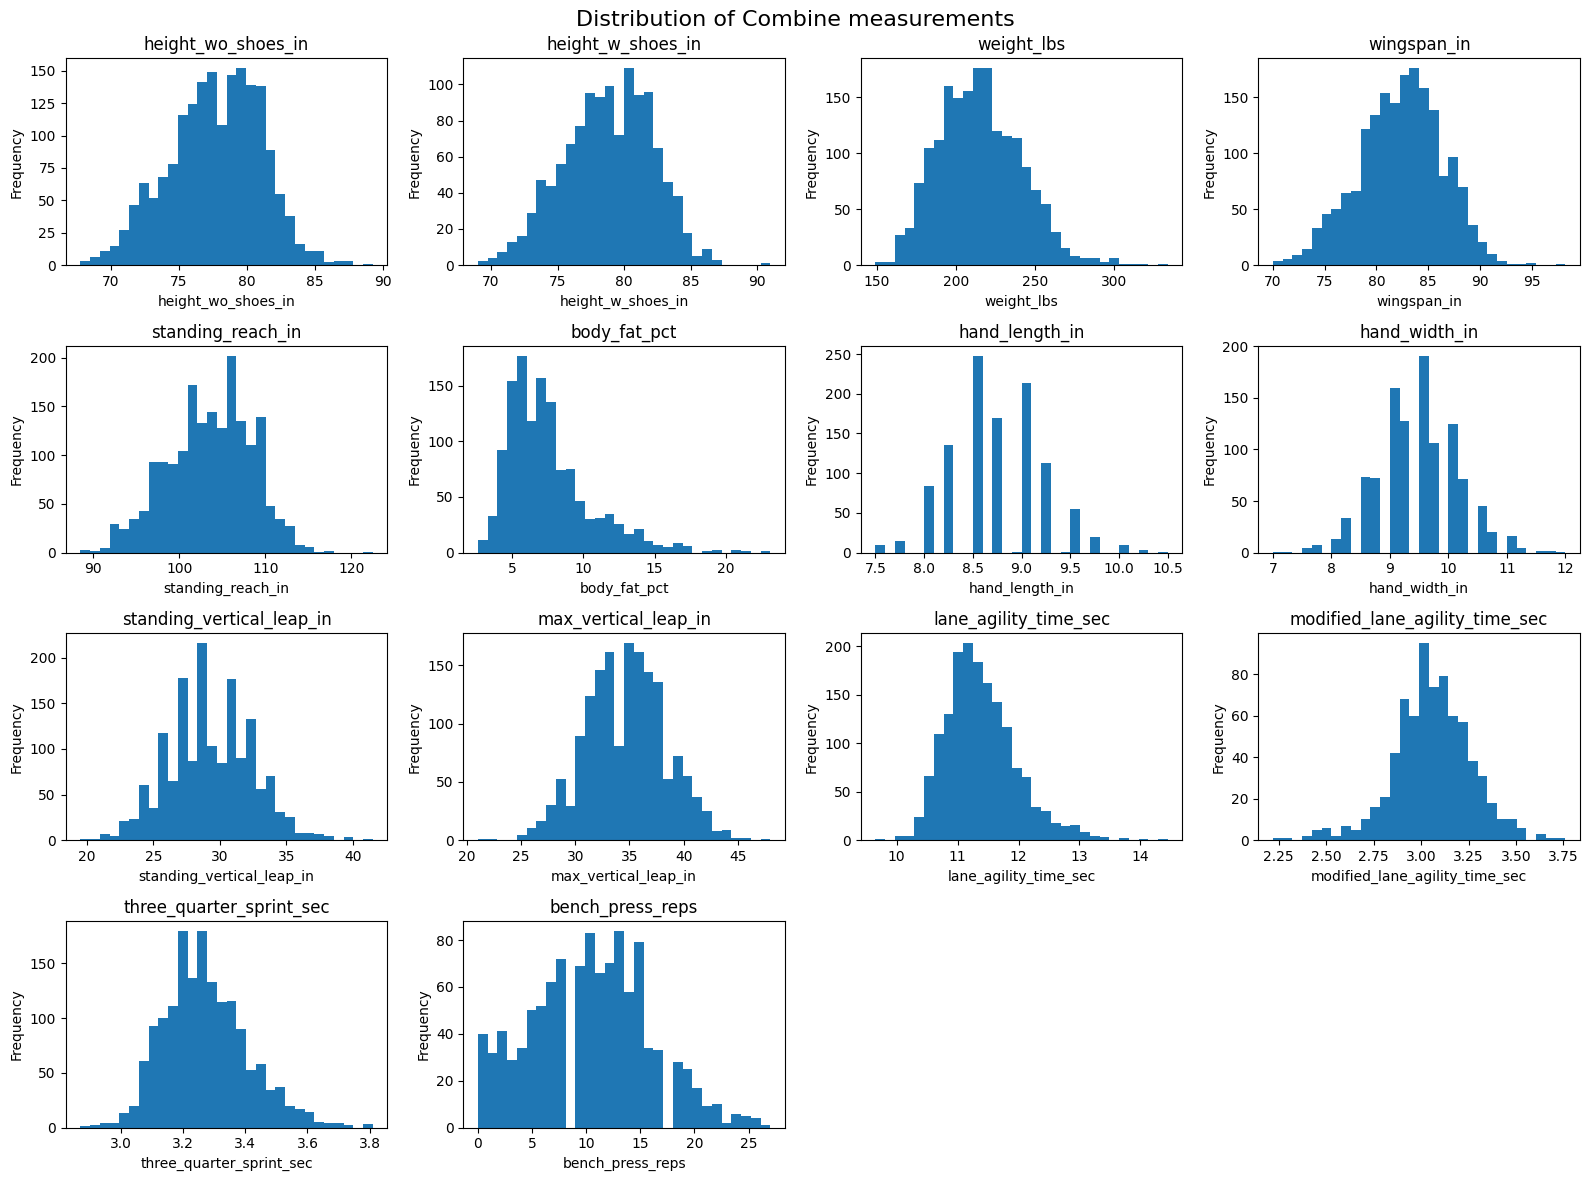

In [10]:
plot_histograms(combine_cols, title=f"Distribution of Combine measurements", bins=30)

In general, the variables are mostly normally distributed. The `body_fat_pct` variable is right-skewed, which is to be expected for a sample of professional athletes. Some variables are not continuous; we see discrete values, which is worth noting. 

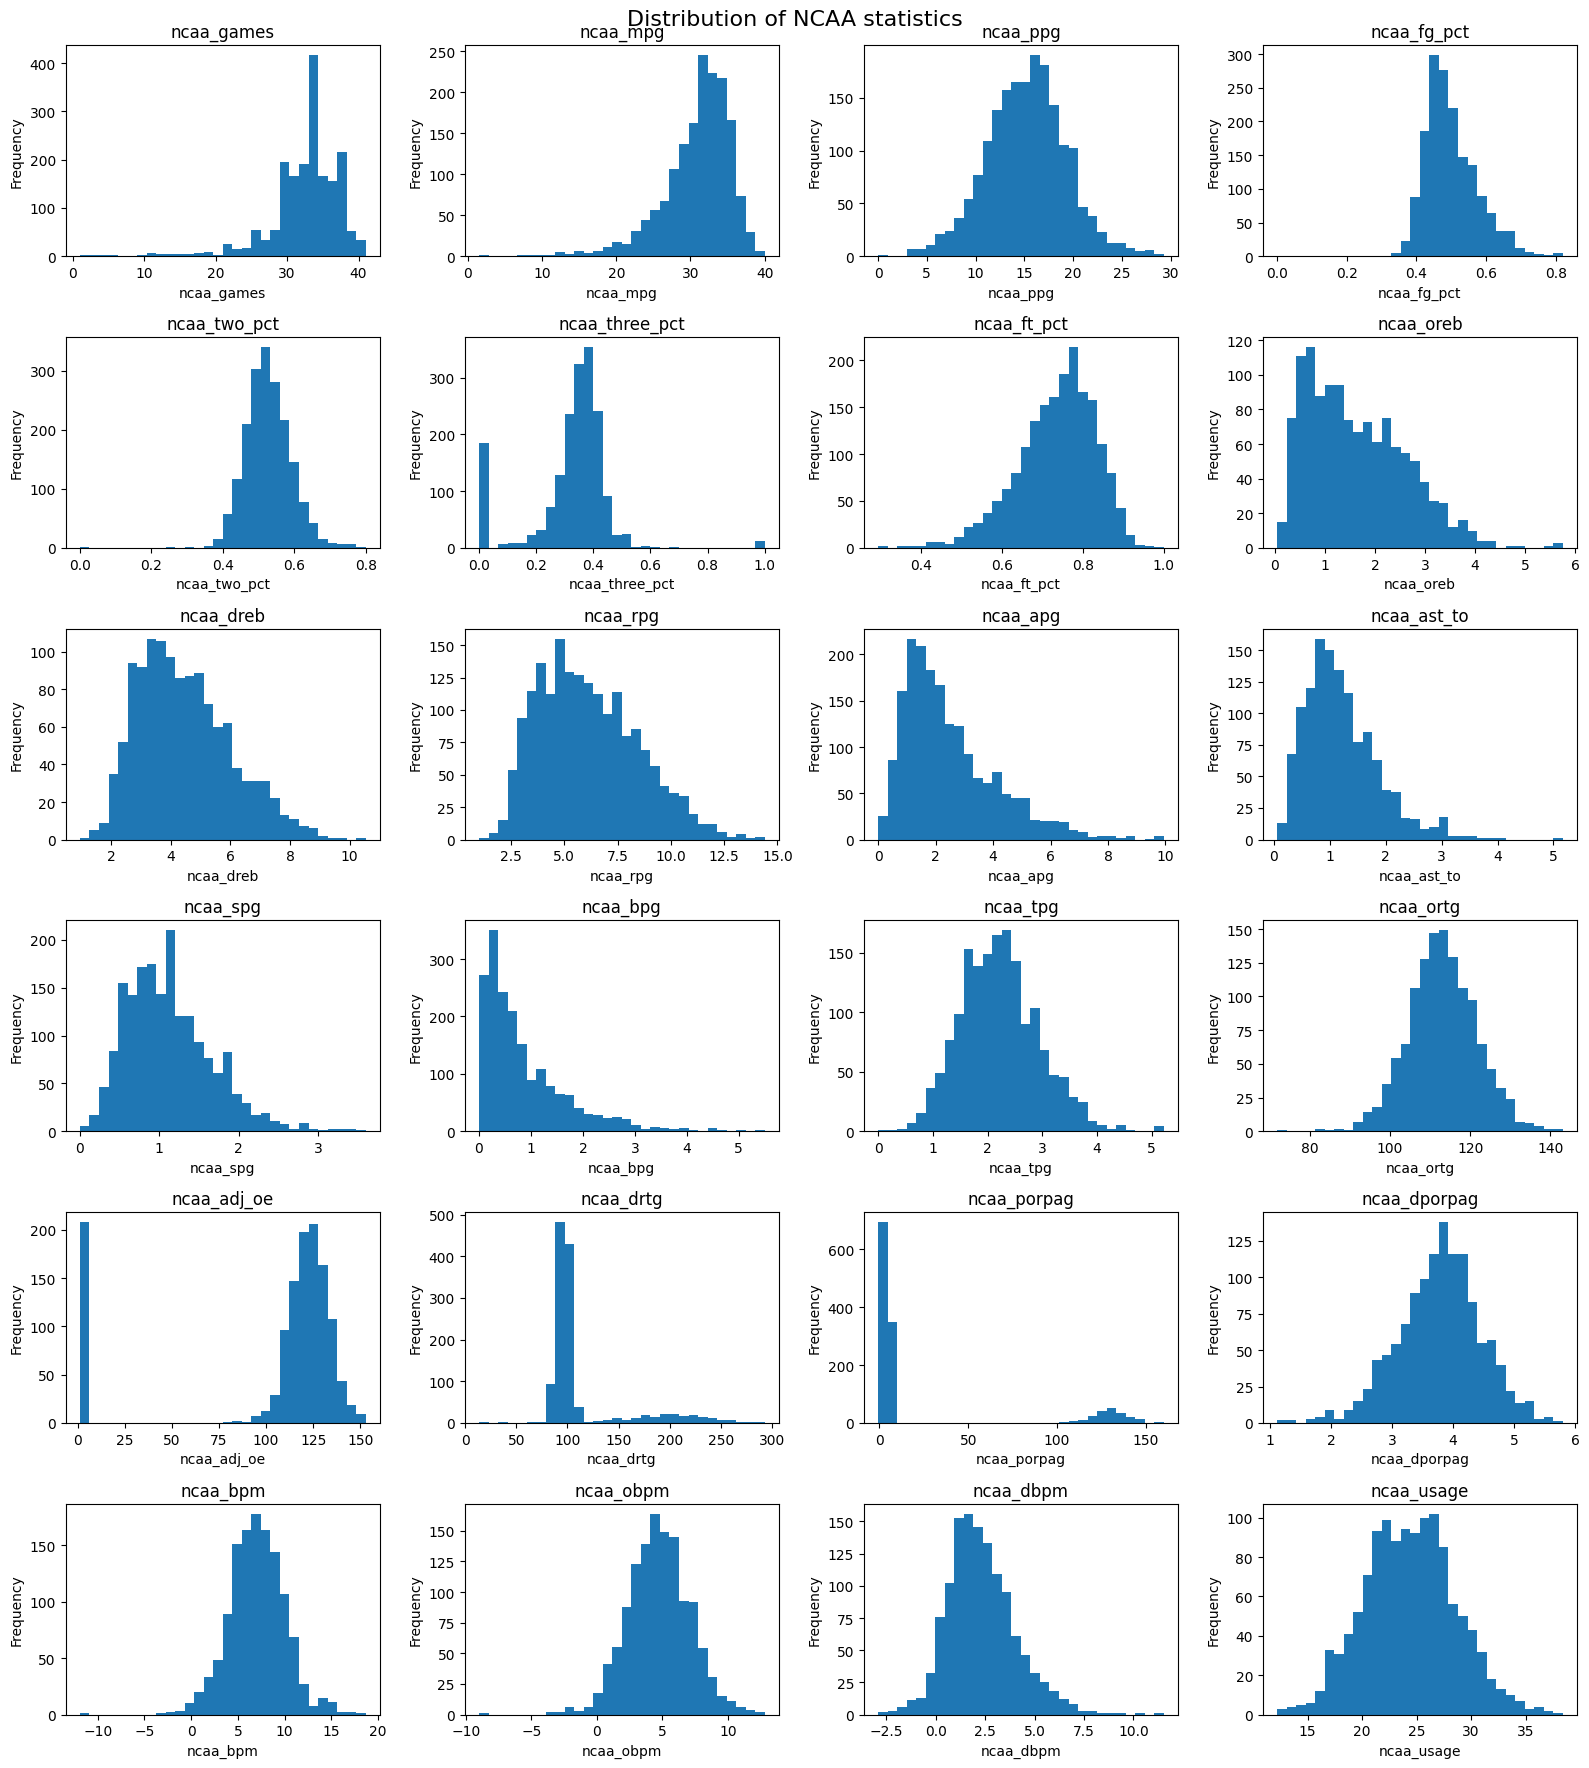

In [11]:
plot_histograms(ncaa_cols, title=f"Distribution of NCAA statistics", bins=30)

Here, the situation is more interesting.
- We have left-skewed variables, such as ncaa_mpg (minutes per game) - this is to be expected, since players entering the draft are more likely to have played a lot in college and been key contributors to their teams. 
- There are also right-skewed variables, such as ncaa_apg, the number of assists per game—this is also logical, since on average players average 1–3 assists per game, but in certain positions (point guard) players average more assists. A similar situation exists, for example, with blocks (ncaa_bpg) and defensive actions—these are common among specialized defensive players. At the same time, all players score points in basketball, so the distribution of ncaa_ppg is close to normal.
- We see some strange isolated peaks for certain variables.

We’ve already discussed the peaks for ncaa_three_pct - 1 is related to a small number of attempts, and 0 is related to the coach’s ban on taking three-point shots for players who aren’t capable of doing so. In essence, paradoxically, the values 0 and 1 here represent similar players who are unable to make long-range shots, and coaches tell them not to do so. 

However, the distributions in the ncaa_adj_oe, ncaa_drtg, and ncaa_porpag columns look strange. These variables should be inspected more carefully before preprocessing and modeling decisions are made.

In [12]:
three_pct_extreme_mask = (
    np.isclose(df["ncaa_three_pct"], 0.0, equal_nan=False)
    | np.isclose(df["ncaa_three_pct"], 1.0, equal_nan=False)
)

print("Players with ncaa_three_pct exactly 0 or 1:")
print(three_pct_extreme_mask.sum())

Players with ncaa_three_pct exactly 0 or 1:
198


If ncaa_three_pct turns out to be an important variable in the future, we need to handle these players with great care or even remove them from the analysis. Unfortunately, we cannot adjust for the number of attempts, as that data is not available. 

Further evidence that this is specifically related to the nature of long-range three-point shots is that we do not observe a large number of such values for other field goal metrics, such as ncaa_fg_pct and ncaa_two_pct. 

In [14]:
context_cols = [
    "name", "draft_year", "overall_pick",
    "position", "organization", "ncaa_games", "ncaa_mpg"
]

suspicious_cols = [
    "ncaa_adj_oe", "ncaa_drtg", "ncaa_porpag"
]

for col in suspicious_cols:
    print(f"\nLowest values for {col}:")
    display(
        df.loc[df[col].notna(), context_cols + [col]]
        .sort_values(col, ascending=True)
        .head(5)
    )
    
    print(f"Highest values for {col}:")
    display(
        df.loc[df[col].notna(), context_cols + [col]]
        .sort_values(col, ascending=False)
        .head(5)
    )


Lowest values for ncaa_adj_oe:


,name,draft_year,overall_pick,position,organization,ncaa_games,ncaa_mpg,ncaa_adj_oe
2132,tyler kolek,2024,34.0,PG,Marquette,31.0,NaN,1.2
2275,anicet dybantsa,2026,NaN,SF,BYU,35.0,NaN,1.4
2178,reece beekman,2024,999.0,PG,Virginia,34.0,NaN,1.5
2216,ryan kalkbrenner,2025,34.0,C,Creighton,35.0,NaN,1.6
2293,ebuka okorie,2026,NaN,PG,Stanford,31.0,NaN,1.6


Highest values for ncaa_adj_oe:


,name,draft_year,overall_pick,position,organization,ncaa_games,ncaa_mpg,ncaa_adj_oe
1672,zion williamson,2019,1.0,PF,Duke,33.0,29.9697,152.849
2098,zach edey,2023,999.0,C,Purdue,34.0,31.7059,152.799
1284,doug mcdermott,2014,11.0,SF,Creighton,35.0,33.7429,151.483
1761,james wiseman,2020,2.0,NaN,Memphis,3.0,23.0000,151.396
1928,keegan murray,2022,4.0,PF,Iowa,35.0,31.8857,150.002



Lowest values for ncaa_drtg:


...

,name,draft_year,overall_pick,position,organization,ncaa_games,ncaa_mpg,ncaa_drtg
2268,yaxel lendeborg,2025,999.0,PF,UAB,36.0,NaN,292.956
2206,nique clifford,2025,24.0,PG-SG,Colorado State,36.0,NaN,282.328
2284,cameron boozer,2026,NaN,PF,Duke,38.0,NaN,279.747
2107,zach edey,2024,9.0,C,Purdue,39.0,NaN,274.419
2111,devin carter,2024,13.0,SG,Providence,33.0,NaN,273.591



Lowest values for ncaa_porpag:


,name,draft_year,overall_pick,position,organization,ncaa_games,ncaa_mpg,ncaa_porpag
1912,makur maker,2021,999.0,C,Howard,1.0,24.0000,-0.789467
1823,kahlil whitney,2020,999.0,SF,Kentucky,18.0,12.6667,-0.059097
1818,jalen harris,2020,59.0,SG,Nevada-Reno,30.0,33.0333,0.082202
1954,peyton watson,2022,30.0,SF,California-Los Angeles,32.0,12.6562,0.124966
1014,daniel orton,2010,29.0,C,Kentucky,38.0,13.2105,0.385170


Highest values for ncaa_porpag:


,name,draft_year,overall_pick,position,organization,ncaa_games,ncaa_mpg,ncaa_porpag
2107,zach edey,2024,9.0,C,Purdue,39.0,NaN,160.039
2284,cameron boozer,2026,NaN,PF,Duke,38.0,NaN,157.717
2281,bruce thornton,2026,NaN,PG,Ohio St.,34.0,NaN,150.105
2316,labaron philon,2026,NaN,PG,Alabama,33.0,NaN,148.652
2345,yaxel lendeborg,2026,NaN,PF,Michigan,40.0,NaN,148.264


We can see that these columns have a very unusual range of values, for example, from -0.78 to 160. Moreover, this isn’t just a single outlier, but a significant number of values. Let’s take a closer look at these columns: 

- ncaa_adj_oe - Adjusted Offensive Efficiency, offensive efficiency, adjusted for opponent strength/context. This is a useful column, and judging by the distribution, there are simply a few outliers here, in the 0–1 range, while the remaining values are normally distributed with a peak around 125. Let’s take a look at the distribution for the filtered column - specifically, for values above the threshold of 5 - without changing the dataset for now:

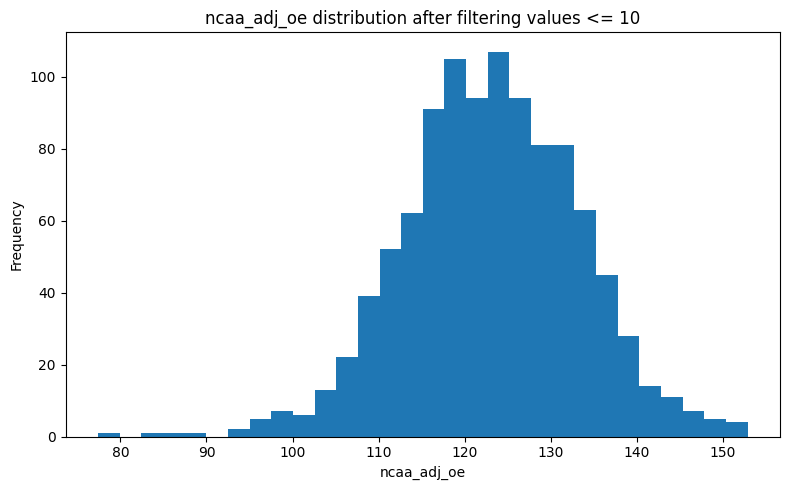

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["ncaa_adj_oe"] > 10, "ncaa_adj_oe"].dropna(), bins=30)
plt.xlabel("ncaa_adj_oe")
plt.ylabel("Frequency")
plt.title("ncaa_adj_oe distribution after filtering values <= 10")
plt.tight_layout()
plt.show()

The column can be saved after removing the outliers. These values were likely obtained for players who played very few minutes - we don't even see any data in the ncaa_mpg column for such players. 

- ncaa_drtg - Defensive Rating - points allowed per 100 possessions; the lower the number, the better. I see outliers on both sides—it seems that the normal value is around 100, but we’re seeing outliers like 13 and 292.

Let’s take a look at the box plot for this variable:

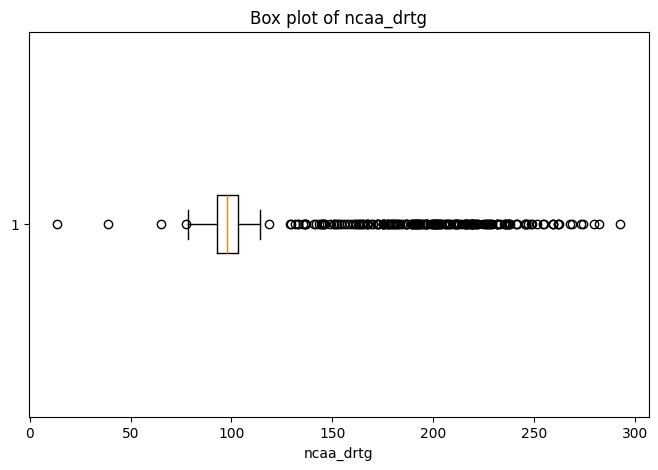

In [16]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["ncaa_drtg"].dropna(), vert=False)
plt.xlabel("ncaa_drtg")
plt.title("Box plot of ncaa_drtg")
plt.show()

Even though there are far more outliers on the right (i.e., values that are unfavorable for players), I would classify both cases as outliers and remove them in the future. These values are likely also related to the small number of minutes played in matches, since with limited playing time, we can see very high or very low values for points allowed per possession.  

- ncaa_porpag - PORPAG = Points Over Replacement Per Adjusted Game - a metric that measures a player’s contribution above replacement level per adjusted game. Normally, this value should be relatively small.

Let’s again take a look at the box plot:

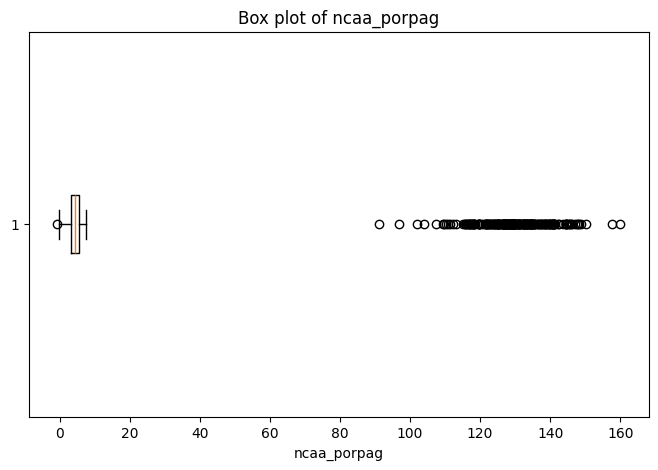

In [17]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["ncaa_porpag"].dropna(), vert=False)
plt.xlabel("ncaa_porpag")
plt.title("Box plot of ncaa_porpag")
plt.show()

We see some unusually high numbers here, which are likely due, once again, to the small number of minutes played. If a player is on the court for just one minute and the team scores like 5 points during that time, it might appear as though the player contributed 160 extra points when scaled to the entire game - which would hardly be accurate if the player were to play the entire match. 

### EDA Step 4: Inspection of categorical variables

Previously, we only checked numerical variables. Let’s quickly check categorical variables for unusual values in the same way:

In [18]:
cat_cols = [
    "position", "organization_type", "organization",
    "ncaa_conf", "ncaa_pos", "ncaa_exp",
    "draft_team_abbreviation"
]

cat_summary = pd.DataFrame({
    "column": cat_cols,
    "non_missing": [df[c].notna().sum() for c in cat_cols],
    "missing": [df[c].isna().sum() for c in cat_cols],
    "n_unique": [df[c].nunique(dropna=True) for c in cat_cols]
})

cat_summary["missing_pct"] = (cat_summary["missing"] / len(df) * 100).round(2)

cat_summary.sort_values(["missing_pct"], ascending=False)

,column,non_missing,missing,n_unique,missing_pct
4,ncaa_pos,1113,1234,8,52.58
5,ncaa_exp,1250,1097,4,46.74
6,draft_team_abbreviation,1542,805,36,34.30
3,ncaa_conf,1849,498,50,21.22
0,position,1868,479,13,20.41
1,organization_type,2226,121,3,5.16
2,organization,2226,121,471,5.16


- ncaa_pos - position on the college team. This variable is very useful for us in categorizing players by position, and having half the values missing is problematic. However, we also have a column called "position", which refers to the position listed on the draft. That column has fewer missing values.
  
- ncaa_exp - status during the final year of college (freshman, senior, etc.). 'draft_age' can partially capture similar information.
  
- ncaa_conf - rarely missing, probably only for players who did not play college basketball at all.
  
- draft_team_abbreviation - it is important to note that this is an anachronic attribute. The name of the team selecting a player in the draft is unknown at the time of the draft, so it SHOULD NOT be used in our prediction. 

Let's check the possible values for the most important variables:

In [19]:
df['position'].value_counts()

position
PF       332
PG       304
SG       279
SF       238
C        178
SG-SF     95
PF-C      83
PG-SG     79
SF-PF     75
C-PF      62
PF-SF     55
SF-SG     48
SG-PG     40
Name: count, dtype: int64

These are all actual positions in basketball, including hybrid ones. 

In [20]:
df['ncaa_conf'].value_counts()

ncaa_conf
SEC          274
ACC          274
B10          163
B12          160
P12          119
BE           118
Big East      82
CUSA          65
Big 12        63
Pac-10        63
MWC           62
Big Ten       57
WCC           46
WAC           32
P10           31
Amer          29
A-10          28
A10           27
MAC           15
OVC           14
CAA           13
MVC           11
SB             9
Horizon        8
Horz           8
MAAC           8
Sun Belt       8
Big Sky        6
Sum            5
BW             5
BSky           4
Big West       4
SC             4
Mid-Cont       4
Ind            3
A-Sun          3
Pat            3
AmEast         3
Southland      2
NEC            2
SWAC           2
BSth           2
Southern       2
MEAC           2
Slnd           1
ind            1
TAAC           1
MW Coll        1
Big South      1
Ivy            1
Name: count, dtype: int64

It’s good that we have a lot of data from the strongest NCAA conferences—the SEC, Big 10, Big 12, and so on. The situation with this variable is manageable, but requires some preprocessing decisions. This is because this variable has 50 unique values, so we cannot simply use one-hot encoding. But it is better than 471 unique values in "organization" (particular team). 

Overall, the situation with categorical variables is good. 

### EDA Step 5: Checking whether we can predict the exact pick value

The original outcome variable in the dataset is overall_pick, which stores the exact NBA Draft pick number. At first glance, this might suggest a regression problem.

However, exact draft pick prediction is likely to be very noisy. Draft position depends not only on a player's pre-draft profile, but also on team needs, draft class strength, scouting uncertainty, injuries, and strategic decisions by teams. 

There is also a technical issue: historical undrafted players are encoded as overall_pick = 999. This value is not a true draft position, but a special marker meaning that the player was not selected. Therefore, treating overall_pick as a continuous numerical variable would incorrectly imply that the distance between pick 60 and 999 is meaningful.

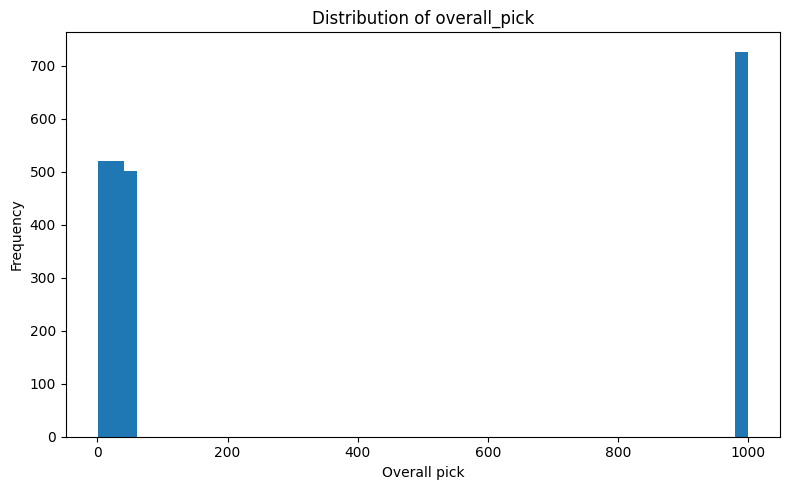

In [21]:
historical = df[df["draft_year"] != 2026].copy()

plt.figure(figsize=(8, 5))
plt.hist(historical["overall_pick"], bins=50)
plt.xlabel("Overall pick")
plt.ylabel("Frequency")
plt.title("Distribution of overall_pick")
plt.tight_layout()
plt.show()

The presence of such values in the data is a problem in itself and leads us to consider shifting our focus to a classification task. However, we cannot simply discard this data - since we also need to be able to predict which teams will pass on selecting a player in the draft, as we do not yet know which 2026 players will be selected and which will not. 

We can also show how moving to groups will reduce noise in the data. Let’s take the most straightforward variable - ncaa_ppg, the average points per game. This variable should be highly correlated with draft position, since scoring a lot of points is the main objective on the court. 

If exact pick were a stable continuous target, we would expect a relatively smooth relationship between player statistics and pick number. However, because each exact pick position contains players from many different years and draft contexts, the relationship may be noisy.

The same variable can also be compared across broader draft outcome groups. If grouped classes show clearer separation than exact pick numbers, this supports the classification approach.

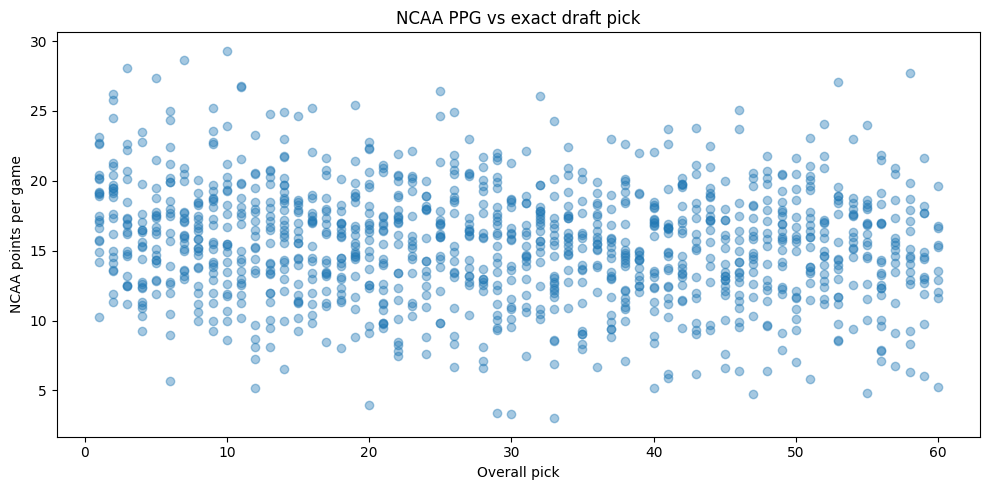

Pearson correlation: -0.136


In [22]:
drafted_ncaa = df[
    (df["draft_year"] != 2026)
    & (df["overall_pick"] != 999)
    & df["ncaa_ppg"].notna()
].copy()

x = drafted_ncaa["overall_pick"]
y = drafted_ncaa["ncaa_ppg"]

plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.4)
plt.xlabel("Overall pick")
plt.ylabel("NCAA points per game")
plt.title("NCAA PPG vs exact draft pick")
plt.tight_layout()
plt.show()

print("Pearson correlation:", round(x.corr(y), 3))

We find almost no correlation in this case. The number of points does decrease slightly as the number increases, but the range is very wide. 

Now let’s try grouping the data as we suggested at the very beginning:

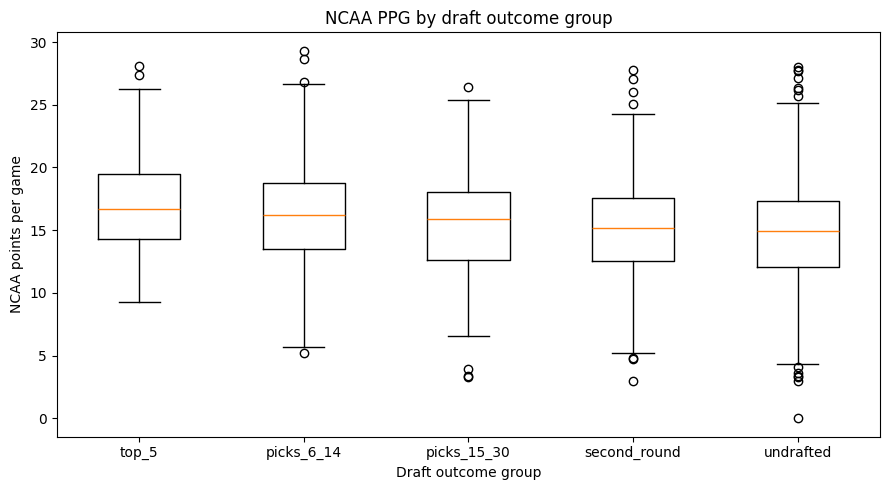

In [23]:
historical_ncaa = df[
    (df["draft_year"] != 2026)
    & df["overall_pick"].notna()
    & df["ncaa_ppg"].notna()
].copy()

def draft_group(pick):
    if pick == 999:
        return "undrafted"
    elif pick <= 5:
        return "top_5"
    elif pick <= 14:
        return "picks_6_14"
    elif pick <= 30:
        return "picks_15_30"
    else:
        return "second_round"

historical_ncaa["draft_group"] = historical_ncaa["overall_pick"].apply(draft_group)

group_order = ["top_5", "picks_6_14", "picks_15_30", "second_round", "undrafted"]

plt.figure(figsize=(9, 5))
plt.boxplot(
    [historical_ncaa.loc[historical_ncaa["draft_group"] == g, "ncaa_ppg"] for g in group_order],
    tick_labels=group_order
)
plt.xlabel("Draft outcome group")
plt.ylabel("NCAA points per game")
plt.title("NCAA PPG by draft outcome group")
plt.tight_layout()
plt.show()

In [24]:
display(
    historical_ncaa
    .groupby("draft_group")["ncaa_ppg"]
    .agg(["count", "mean", "median", "std"])
    .loc[group_order]
    .round(2)
)

,count,mean,median,std
draft_group,,,,
top_5,101,16.98,16.69,3.95
picks_6_14,196,16.25,16.22,4.31
picks_15_30,321,15.42,15.90,4.02
second_round,548,15.03,15.14,3.92
undrafted,608,14.75,14.92,4.10


Although the decrease in the average score is still small, and it is too early to speak of a correlation, a certain trend in the average values can be observed. 

Overall, a single variable should not be considered a strong indicator here; however, it is clear that this approach can be effective in reducing noise in the data. 

### EDA Step 6: Are numerical variables comparable across draft years?

Raw numerical statistics may not be fully comparable across draft years. Each draft class is a different pool of players, and the overall strength of the class may vary. Therefore, the same absolute value can have different meanings in different years. 

For this reason, it may be useful to transform some numerical variables into year-relative values.

For example, let's convert ncaa_ppg into a draft-year-relative z-score:

`ncaa_ppg_year_z = (player ncaa_ppg - draft-year mean ncaa_ppg) / draft-year standard deviation`

This transformation is only used for visualizations on this stage and does not modify the original dataset.

In [25]:
ppg_year = df[
    (df["draft_year"] != 2026)
    & df["overall_pick"].notna()
    & df["ncaa_ppg"].notna()
].copy()

ppg_year["ncaa_ppg_year_mean"] = ppg_year.groupby("draft_year")["ncaa_ppg"].transform("mean")
ppg_year["ncaa_ppg_year_std"] = ppg_year.groupby("draft_year")["ncaa_ppg"].transform("std")

ppg_year["ncaa_ppg_year_z"] = (
    (ppg_year["ncaa_ppg"] - ppg_year["ncaa_ppg_year_mean"]) / ppg_year["ncaa_ppg_year_std"]
)

ppg_year["draft_group"] = ppg_year["overall_pick"].apply(draft_group)

ppg_year[["name", "draft_year", "overall_pick", "ncaa_ppg",
         "ncaa_ppg_year_mean", "ncaa_ppg_year_std", "ncaa_ppg_year_z", "draft_group"]].head()

,name,draft_year,overall_pick,ncaa_ppg,ncaa_ppg_year_mean,ncaa_ppg_year_std,ncaa_ppg_year_z,draft_group
0,kenyon martin,2000,1.0,18.9,14.990909,3.956446,0.988031,top_5
1,stromile swift,2000,2.0,16.2,14.990909,3.956446,0.305600,top_5
3,marcus fizer,2000,4.0,22.8,14.990909,3.956446,1.973764,top_5
4,mike miller,2000,5.0,14.1,14.990909,3.956446,-0.225179,top_5
5,dermarr johnson,2000,6.0,12.6,14.990909,3.956446,-0.604307,picks_6_14


Now let’s plot graphs exactly like the ones in the previous section, but for our new (temporarily!) transformed variable

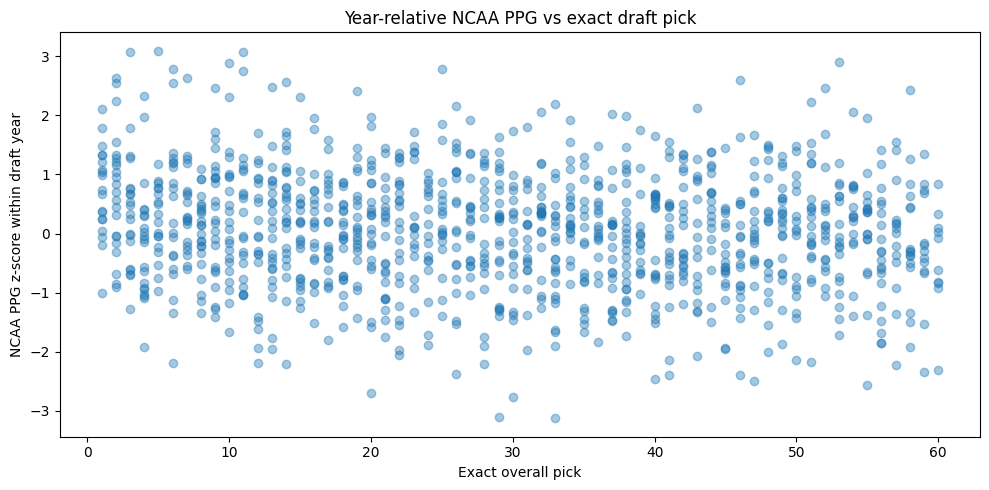

Pearson correlation: -0.136


In [26]:
drafted_ppg_year = ppg_year[ppg_year["overall_pick"] != 999].copy()

x = drafted_ppg_year["overall_pick"]
y = drafted_ppg_year["ncaa_ppg_year_z"]

plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.4)
plt.xlabel("Exact overall pick")
plt.ylabel("NCAA PPG z-score within draft year")
plt.title("Year-relative NCAA PPG vs exact draft pick")
plt.tight_layout()
plt.show()

print("Pearson correlation:", round(x.corr(y), 3))

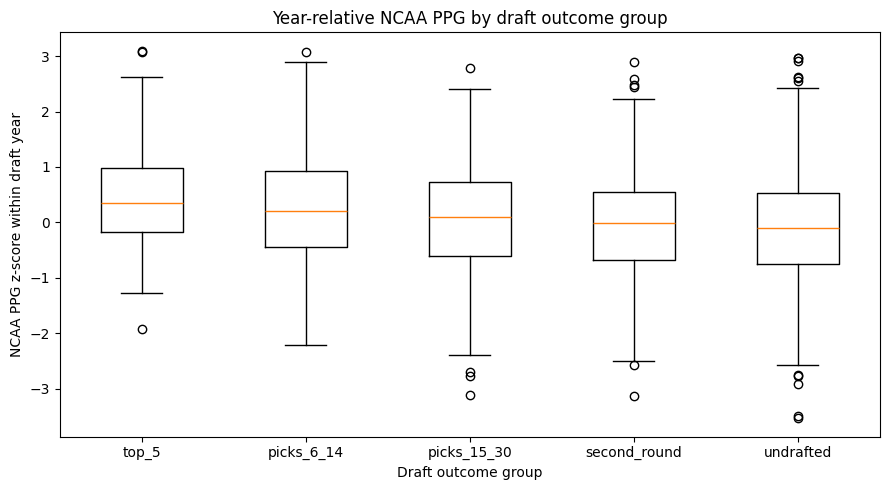

,count,mean,median,std
draft_group,,,,
top_5,101,0.41,0.36,0.98
picks_6_14,196,0.23,0.21,1.04
picks_15_30,321,0.04,0.09,0.97
second_round,548,-0.06,-0.02,0.95
undrafted,608,-0.11,-0.10,1.00


In [27]:
plt.figure(figsize=(9, 5))
plt.boxplot(
    [ppg_year.loc[ppg_year["draft_group"] == g, "ncaa_ppg_year_z"] for g in group_order],
    tick_labels=group_order
)
plt.xlabel("Draft outcome group")
plt.ylabel("NCAA PPG z-score within draft year")
plt.title("Year-relative NCAA PPG by draft outcome group")
plt.tight_layout()
plt.show()

display(
    ppg_year
    .groupby("draft_group")["ncaa_ppg_year_z"]
    .agg(["count", "mean", "median", "std"])
    .loc[group_order]
    .round(2)
)

In fact, there’s no visible difference at all. Perhaps top_5 players are, on average, about half a standard deviation above the yearly NCAA PPG mean, while undrafted players are slightly below it, but the effect still doesn’t seem significant. This would be the expected result if we had performed a standard z-score transformation, but since we adjusted for the years, the result is strange. 

Let’s check how much the average scores actually differ by year. 

In [28]:
ppg_year.groupby("draft_year").agg(
        mean_raw_ppg=("ncaa_ppg", "mean"),
        std_raw_ppg=("ncaa_ppg", "std"),
    ).round(2)

,mean_raw_ppg,std_raw_ppg
draft_year,,
2000,14.99,3.96
2001,14.66,4.31
2002,16.28,4.12
2003,16.02,4.69
2004,15.68,4.25
2005,15.19,4.30
2006,15.68,4.04
2007,15.54,3.91
2008,15.17,4.34


Average NCAA PPG differs between draft years, but this variation is smaller than the standard deviation within each year. In other words, the scoring distribution is relatively stable across draft classes. 

This likely means that we have actually overestimated the extent to which players from different years differ from one another. This suggests that year-based transformation should not be applied blindly to all numerical variables. Instead, it can be considered as an alternative preprocessing strategy and evaluated later during modeling. 

In summary, we now know that we need to focus on college players, remove certain variables with a high number of missing values, exclude outliers from the advanced NCAA metrics, convert the target variable to a categorical one, and optionally perform a z-score year-related transformation. 

# Phase 4 - Data Preprocessing

The purpose of this phase is to transform the raw analytical dataset into a format suitable for our models. 

Based on the exploratory analysis, several preprocessing decisions are necessary:

- transform the original overall_pick variable into a multiclass target variable;
- separate historical observations from the 2026 prediction pool;
- focus on college players;
- remove anachronic and non-predictive attributes;
- handle missing values;
- handle outliers in selected numerical variables;
- encode categorical variables;
- prepare feature sets for model comparison.

### Preprocessing Step 1 - target variable transformation

The original outcome variable, overall_pick, is converted into a multiclass target variable called draft_group.

The planned classes are:

- top_5: picks 1–5
- picks_6_14: picks 6–14
- picks_15_30: picks 15–30
- second_round: picks 31–60
- undrafted: historical players encoded as overall_pick = 999

In [29]:
df_prep = df.copy()

def make_draft_group(row):
    year = row["draft_year"]
    pick = row["overall_pick"]
    
    if year == 2026:
        return np.nan
    
    if pick == 999:
        return "undrafted"
    elif 1 <= pick <= 5:
        return "top_5"
    elif 6 <= pick <= 14:
        return "picks_6_14"
    elif 15 <= pick <= 30:
        return "picks_15_30"
    elif 31 <= pick <= 60:
        return "second_round"

df_prep["draft_group"] = df_prep.apply(make_draft_group, axis=1)

historical_data = df_prep[df_prep["draft_year"] != 2026].copy()
prediction_2026 = df_prep[df_prep["draft_year"] == 2026].copy()

print("Full dataset:", df_prep.shape[0])
print("Historical data:", historical_data.shape[0])
print("2026 prediction pool:", prediction_2026.shape[0])

print("\nFor historical data:")
display(
    historical_data["draft_group"]
    .value_counts()
    .rename_axis("draft_group")
    .reset_index(name="rows")
)

Full dataset: 2347
Historical data: 2269
2026 prediction pool: 78

For historical data:


,draft_group,rows
0,second_round,762
1,undrafted,727
2,picks_15_30,416
3,picks_6_14,234
4,top_5,130


For further analysis and evaluation of the models, it is important to note that there is an imbalance between the classes. 

### Preprocessing Step 2 - removing players without college statistics from the data

Pre-draft game statistics are missing for non-college players, such as international club players and high school players. Since such variables are expected to be one of the most informative parts of the dataset, and they are available only in the NCAA performance format, the main model will focus on players with an available NCAA statistical profile.

In [30]:
historical_ncaa = historical_data[historical_data[ncaa_cols].notna().any(axis=1)].copy()
prediction_2026_ncaa = prediction_2026[prediction_2026[ncaa_cols].notna().any(axis=1)].copy()

print("Historical data before NCAA filter:", historical_data.shape)
print("Historical data after NCAA filter:", historical_ncaa.shape)

print("\n2026 prediction pool before NCAA filter:", prediction_2026.shape)
print("2026 prediction pool after NCAA filter:", prediction_2026_ncaa.shape)

Historical data before NCAA filter: (2269, 52)
Historical data after NCAA filter: (1775, 52)

2026 prediction pool before NCAA filter: (78, 52)
2026 prediction pool after NCAA filter: (74, 52)


In [31]:
historical_ncaa["draft_group"].value_counts()

draft_group
undrafted       608
second_round    549
picks_15_30     321
picks_6_14      196
top_5           101
Name: count, dtype: int64

We removed a significant portion of the data, but there is still enough left for further analysis. 

The class distribution has not changed significantly - it's still unbalanced, but in the same way. 

### Preprocessing Step 3 - removing anachronic and non-predictive attributes

Several columns are excluded for methodological reasons:

- name: player identifier, but it is better to stay just with index; 
- overall_pick: the original outcome variable used to construct the target, save only the target variable itself;
- draft_team_abbreviation: an anachronic attribute known only after draft selection;
- birth_date: raw date variable; draft_age is more directly useful;
- draft_year: context variable used for splitting and possible year-relative transformations, not an ordinary predictor;
- organization: high-cardinality categorical variable that may cause overfitting in the first model. Better to stay just on 'conference' - still save the team strength, but less variable;
- organization_type - single value for now, only college students; 
- ncaa_pos: highly incomplete and redundant with 'position';
- ncaa_height: text-based height variable, partly redundant with numerical height measurements.

draft_year is kept temporarily for possible year-relative feature engineering, but it will not be used as a regular model predictor

In [32]:
model_data = historical_ncaa.copy()
prediction_data = prediction_2026_ncaa.copy()

excluded_cols = [
    "name",
    "overall_pick",
    "draft_group",
    "draft_team_abbreviation",
    "birth_date",
    "organization",
    "organization_type",
    "ncaa_pos",
    "ncaa_height"
]

feature_cols = [
    col for col in model_data.columns
    if col not in excluded_cols
]

target_col = "draft_group"

X_raw = model_data[feature_cols].copy()
y = model_data[target_col].copy()

X_2026_raw = prediction_data[feature_cols].copy()

print("Historical feature matrix shape:", X_raw.shape)
print("2026 feature matrix shape:", X_2026_raw.shape)

Historical feature matrix shape: (1775, 43)
2026 feature matrix shape: (74, 43)


### Preprocessing Step 4 - inspect candidate features about missing values percentage 

In [33]:
numeric_features = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_raw.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numeric features: 40
Number of categorical features: 3


Let’s take another look at our situation with the missing values after the initial filtering

In [34]:
missing_after_filter = pd.DataFrame({
    "feature": X_raw.columns,
    "dtype": X_raw.dtypes.astype(str).values,
    "missing": X_raw.isna().sum().values,
    "missing_pct": (X_raw.isna().mean().values * 100).round(2),
    "n_unique": X_raw.nunique(dropna=True).values
}).sort_values("missing_pct", ascending=False)

missing_after_filter

,feature,dtype,missing,missing_pct,n_unique
13,modified_lane_agility_time_sec,float64,1193,67.21,108
8,hand_length_in,float64,881,49.63,13
9,hand_width_in,float64,881,49.63,20
15,bench_press_reps,float64,818,46.08,28
3,height_w_shoes_in,float64,697,39.27,80
7,body_fat_pct,float64,639,36.00,190
26,ncaa_dreb,float64,600,33.80,867
25,ncaa_oreb,float64,600,33.80,721
29,ncaa_ast_to,float64,600,33.80,1151
34,ncaa_adj_oe,float64,599,33.75,1057


There are still some observations missing key values, such as average points per game. Let’s remove those as well. 

In [35]:
core_ncaa_cols = [
    "ncaa_ppg", "ncaa_rpg", "ncaa_apg",
    "ncaa_spg", "ncaa_bpg", "ncaa_ft_pct"
]
model_data[model_data[core_ncaa_cols].isna().any(axis=1)]

,name,draft_year,overall_pick,position,organization,organization_type,draft_team_abbreviation,height_wo_shoes_in,height_w_shoes_in,weight_lbs,...,ncaa_drtg,ncaa_porpag,ncaa_dporpag,ncaa_bpm,ncaa_obpm,ncaa_dbpm,ncaa_usage,birth_date,draft_age,draft_group
573,chris thomas,2005,999.0,PG,Weber St.,College/University,NaN,71.75,73.0,176.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,undrafted
2236,taelon peter,2025,54.0,NaN,Liberty,College/University,IND,NaN,NaN,NaN,...,145.313,135.337,2.77175,7.20552,5.93556,1.26996,20.8,2002-02-27,23.324,second_round


In [36]:
rows_to_remove = (
    ((model_data["name"] == "chris thomas") & (model_data["draft_year"] == 2005)) |
    ((model_data["name"] == "taelon peter") & (model_data["draft_year"] == 2025))
)

model_data = model_data.loc[~rows_to_remove].copy()
X_raw = model_data[feature_cols].copy()
y = model_data[target_col].copy()

Also, some combine variables still have a high percentage of missing values (close to 50%). In addition, height_w_shoes_in is partly redundant with height_wo_shoes_in, while having substantially more missing values. 

Let's remove the most empty or useless columns. 

In [37]:
cols_to_drop_sparse_redundant = [
    "height_w_shoes_in",
    "modified_lane_agility_time_sec",
    "hand_length_in",
    "hand_width_in",
    "bench_press_reps"
]

feature_cols_clean = [
    col for col in feature_cols
    if col not in cols_to_drop_sparse_redundant
]

X_raw = model_data[feature_cols_clean].copy()
X_2026_raw = prediction_data[feature_cols_clean].copy()

print("Feature matrix after dropping sparse/redundant columns:", X_raw.shape)
print("2026 feature matrix after dropping sparse/redundant columns:", X_2026_raw.shape)

Feature matrix after dropping sparse/redundant columns: (1773, 38)
2026 feature matrix after dropping sparse/redundant columns: (74, 38)


### Preprocessing Step 5 - handling outliers in advanced NCAA metrics

During EDA, several advanced NCAA metrics showed values that were not comparable with the main distribution of the same variables.

Instead of removing entire players, suspicious values are replaced with missing values. They will later be handled by the same imputation strategy as other missing numerical values.

In [38]:
advanced_outlier_cols = [
    "ncaa_adj_oe",
    "ncaa_drtg",
    "ncaa_porpag"
]

X_clean = X_raw.copy()
X_2026_clean = X_2026_raw.copy()

iqr_summary = []

for col in advanced_outlier_cols:
    q1 = X_clean[col].quantile(0.25)
    q3 = X_clean[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    train_mask = (X_clean[col] < lower) | (X_clean[col] > upper)
    pred_mask = (X_2026_clean[col] < lower) | (X_2026_clean[col] > upper)
    
    iqr_summary.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "historical_values_replaced": train_mask.sum(),
        "prediction_2026_values_replaced": pred_mask.sum()
    })
    
    X_clean.loc[train_mask, col] = np.nan
    X_2026_clean.loc[pred_mask, col] = np.nan

display(pd.DataFrame(iqr_summary).round(3))

,feature,lower_bound,upper_bound,historical_values_replaced,prediction_2026_values_replaced
0,ncaa_adj_oe,88.977,153.163,137,74
1,ncaa_drtg,78.412,116.490,130,73
2,ncaa_porpag,0.065,8.547,135,74


So, on this stage the IQR-based outlier check showed that all 2026 values for ncaa_adj_oe, ncaa_drtg, and ncaa_porpag fall outside the historical range. This suggests that the issue is not a small number of outliers, but a systematic scale or source inconsistency between historical data and the 2026 prediction pool.

Since the main goal of the project is to predict 2026 draft outcomes, these variables should not be used in the modeling feature set. 

So, in the end, even though the historical data identified these as simply outliers, I’ve decided not to use these columns at all due to a potential issue with the training dataset. 

In [39]:
X_clean = X_raw.drop(columns=advanced_outlier_cols).copy()
X_2026_clean = X_2026_raw.drop(columns=advanced_outlier_cols).copy()

print("X_clean shape:", X_clean.shape)
print("X_2026_clean shape:", X_2026_clean.shape)

X_clean shape: (1773, 35)
X_2026_clean shape: (74, 35)


### Preprocessing Step 6 - imputation, encoding and scaling strategy for the remaining features

Even after filtering, dataset still contains a lot of missing values. Since the goal is predictive modeling, the remaining missing values must be handled before training machine learning models.

For numerical variables, missing values are imputed using the median value within the same player position. This is more appropriate than using one global median because many basketball statistics and physical measurements depend strongly on position (but, in case of missing data for a certain position, the global median is used). Of course, in many cases this is a bad option, but we made sure that we didn't have missing values in the most important columns earlier.

For categorical variables, missing values are replaced with a separate "Unknown" category.

Finally, numerical variables are scaled (important for some planned models) and categorical variables are one-hot encoded. 

In [40]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# draft_year is kept as a helper column in case of transformation, but not used as a predictor

model_feature_cols = [
    col for col in X_clean.columns
    if col not in ["draft_year"]
]
X_model = X_clean[model_feature_cols].copy()
X_2026_model = X_2026_clean[model_feature_cols].copy()

numeric_features = X_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_model.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", categorical_features)

Numerical features: 31
Categorical features: ['position', 'ncaa_conf', 'ncaa_exp']


In [41]:
def impute_numeric_by_position(X):
    X_out = X.copy()
    for col in numeric_features:
        position_values = X_out["position"].map(position_medians[col])
        X_out[col] = X_out[col].fillna(position_values)
        X_out[col] = X_out[col].fillna(global_medians[col])
    
    return X_out

position_medians = X_model.groupby("position")[numeric_features].median()
global_medians = X_model[numeric_features].median()

X_imputed = impute_numeric_by_position(X_model)
X_2026_imputed = impute_numeric_by_position(X_2026_model)

X_imputed[categorical_features] = X_imputed[categorical_features].fillna("Unknown")
X_2026_imputed[categorical_features] = X_2026_imputed[categorical_features].fillna("Unknown")

print("Missing values after imputation:")
print("Historical:", X_imputed.isna().sum().sum())
print("2026:", X_2026_imputed.isna().sum().sum())

Missing values after imputation:
Historical: 0
2026: 0


In [42]:
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed[numeric_features]),
    columns=numeric_features,
    index=X_imputed.index
)

X_2026_num_scaled = pd.DataFrame(
    scaler.transform(X_2026_imputed[numeric_features]),
    columns=numeric_features,
    index=X_2026_imputed.index
)

X_cat_encoded = pd.DataFrame(
    encoder.fit_transform(X_imputed[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_imputed.index
)

X_2026_cat_encoded = pd.DataFrame(
    encoder.transform(X_2026_imputed[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_2026_imputed.index
)

X_processed = pd.concat([X_num_scaled, X_cat_encoded], axis=1)
X_2026_processed = pd.concat([X_2026_num_scaled, X_2026_cat_encoded], axis=1)

print("Processed historical feature matrix:", X_processed.shape)
print("Processed 2026 feature matrix:", X_2026_processed.shape)

Processed historical feature matrix: (1773, 100)
Processed 2026 feature matrix: (74, 100)


After imputation, scaling, and one-hot encoding, the feature matrices contain no missing values. All predictors are numerical and can be used by the planned models. 

In [43]:
X_final = X_processed.copy()
X_2026_final = X_2026_processed.copy()
y_final = y.loc[X_final.index].copy()

# Phase 5 - Modeling

The cleaned historical dataset is used to train and compare several machine learning models. Since the real 2026 draft outcomes are not yet available, the 2026 dataset is treated as a prediction pool rather than as a true test set. But it would be interesting to try making a prediction using it, without evaluating its accuracy just yet. Perhaps it would be worth comparing the models results for 2026 with experts predictions. 

To compare models before predicting 2026, the historical data is split into training and validation subsets. Stratification preserves the distribution of draft outcome classes in both subsets.

### Modeling Step 1 - data split

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score

y_model = y.loc[X_clean.index].copy()

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_clean,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Train:", X_train_raw.shape)
print("Validation:", X_val_raw.shape)

Train: (1418, 35)
Validation: (355, 35)


In [45]:
y_train.value_counts()

draft_group
undrafted       485
second_round    438
picks_15_30     257
picks_6_14      157
top_5            81
Name: count, dtype: int64

In [46]:
y_val.value_counts()

draft_group
undrafted       122
second_round    110
picks_15_30      64
picks_6_14       39
top_5            20
Name: count, dtype: int64

### Modeling Step 2 - train and validation preprocessing 

For model validation, preprocessing is not applied to the full historical dataset before the train-validation split. 

Instead, the split is performed first, and imputation, scaling, and encoding are fitted only on the training subset. The validation subset is then transformed using the preprocessing parameters learned from the training data. This prevents information from the validation distribution from influencing the training process.

We will repeat the same preprocessing strategy from the last step of phase 4, fitted only on training data

In [47]:
def preprocess(X_train_raw, X_other_raw):
    
    X_train = X_train_raw.drop(columns=["draft_year"]).copy()
    X_other = X_other_raw.drop(columns=["draft_year"]).copy()
    
    num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    
    position_medians = X_train.groupby("position")[num_cols].median()
    global_medians = X_train[num_cols].median()
    
    def impute(X):
        X_out = X.copy()
        for col in num_cols:
            position_values = X_out["position"].map(position_medians[col])
            X_out[col] = X_out[col].fillna(position_values)
            X_out[col] = X_out[col].fillna(global_medians[col])
        X_out[cat_cols] = X_out[cat_cols].fillna("Unknown")
        return X_out
    
    X_train_imp = impute(X_train)
    X_other_imp = impute(X_other)
    
    scaler = StandardScaler()
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    
    X_train_num = pd.DataFrame(
        scaler.fit_transform(X_train_imp[num_cols]),
        columns=num_cols,
        index=X_train_imp.index
    )
    X_other_num = pd.DataFrame(
        scaler.transform(X_other_imp[num_cols]),
        columns=num_cols,
        index=X_other_imp.index
    )
    X_train_cat = pd.DataFrame(
        encoder.fit_transform(X_train_imp[cat_cols]),
        columns=encoder.get_feature_names_out(cat_cols),
        index=X_train_imp.index
    )
    X_other_cat = pd.DataFrame(
        encoder.transform(X_other_imp[cat_cols]),
        columns=encoder.get_feature_names_out(cat_cols),
        index=X_other_imp.index
    )
    
    return (
        pd.concat([X_train_num, X_train_cat], axis=1),
        pd.concat([X_other_num, X_other_cat], axis=1)
    )

X_train, X_val = preprocess(X_train_raw, X_val_raw)

print("Processed train:", X_train.shape)
print("Processed validation:", X_val.shape)
print("Missing train:", X_train.isna().sum().sum())
print("Missing validation:", X_val.isna().sum().sum())

Processed train: (1418, 99)
Processed validation: (355, 99)
Missing train: 0
Missing validation: 0


Before we had 100 columns

In [48]:
missing_columns = sorted(set(X_processed.columns) - set(X_train.columns))
missing_columns

['ncaa_conf_TAAC']

Ok, just some rare conference that wasn't included in the train. Shouldn't cause any problems.

While testing different models, let’s decide on the evaluation metrics. For the final prediction, evaluation will be performed separately in step 6, but we will also evaluate the models during step 5 to help us select the best ones.

Usual accuracy measures the overall proportion of correct predictions. However, in this task the classes are imbalanced, so a model can achieve non-zero accuracy by mostly predicting the largest classes. So, here we will focus on balanced accuracy. It calculates recall separately for each class and then averages the recalls. This helps evaluate whether the model can recognize all draft outcome groups, rather than only the most frequent ones.

Also, macro F1 is used instead of usual one, because it calculates F1-score separately for each draft group and then averages them equally. This makes performance on smaller classes, such as top_5, just as important as performance on larger classes.

### Modeling Step 3 - Dummy Classifier

The first model we'll try is a DummyClassifier for the most common class. Obviously, such a model won't predict anything in our case, but it will simply serve as a baseline. 

In [49]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_val_pred_dummy = dummy.predict(X_val)

print("Dummy Classifier")
print("Macro F1:", round(f1_score(y_val, y_val_pred_dummy, average="macro"), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_val, y_val_pred_dummy), 4))

print("\nClassification report:")
print(classification_report(
    y_val,
    y_val_pred_dummy,
    labels=group_order,
    zero_division=0
))

cm_dummy = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_dummy, labels=group_order),
    index=[f"true_{c}" for c in group_order],
    columns=[f"pred_{c}" for c in group_order]
)

cm_dummy

Dummy Classifier
Macro F1: 0.1023
Balanced accuracy: 0.2

Classification report:
              precision    recall  f1-score   support

       top_5       0.00      0.00      0.00        20
  picks_6_14       0.00      0.00      0.00        39
 picks_15_30       0.00      0.00      0.00        64
second_round       0.00      0.00      0.00       110
   undrafted       0.34      1.00      0.51       122

    accuracy                           0.34       355
   macro avg       0.07      0.20      0.10       355
weighted avg       0.12      0.34      0.18       355



,pred_top_5,pred_picks_6_14,pred_picks_15_30,pred_second_round,pred_undrafted
true_top_5,0,0,0,0,20
true_picks_6_14,0,0,0,0,39
true_picks_15_30,0,0,0,0,64
true_second_round,0,0,0,0,110
true_undrafted,0,0,0,0,122


The Dummy Classifier predicts only the majority class, undrafted. As a result, it reaches an accuracy of 0.34, but this comes entirely from correctly identifying some undrafted players.

The model has zero recall and zero F1-score for all drafted groups. This makes it a useful baseline: any meaningful model should improve not only overall accuracy, but also macro F1 and balanced accuracy.

We will reuse the same evaluation method for different models and save the results in a single dataset. 

In [58]:
def evaluate_model(model_name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    
    print(model_name)
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))
    
    print("\nClassification report:")
    print(classification_report(
        y_val,
        y_pred,
        labels=group_order,
        zero_division=0
    ))
    
    cm = pd.DataFrame(
        confusion_matrix(y_val, y_pred, labels=group_order),
        index=[f"true_{c}" for c in group_order],
        columns=[f"pred_{c}" for c in group_order]
    )
    
    display(cm)
    
    return {
        "model": model_name,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc
    }, y_pred

In [88]:
model_results = []

model_results.append({
    "model": "Dummy Classifier",
    "macro_f1": 0.1023,
    "balanced_accuracy": 0.2000
})

pd.DataFrame(model_results)

,model,macro_f1,balanced_accuracy
0,Dummy Classifier,0.1023,0.2


### Modeling Step 4 - Logistic Regression

Now let’s try a more advanced classification model: logistic regression. 

Given the characteristics of our data, we’ll use the `class_weight=“balanced”` parameter. 

In [60]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

log_reg_results, y_val_pred_log_reg = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_train,
    y_train,
    X_val,
    y_val
)

Logistic Regression
Macro F1: 0.4374
Balanced accuracy: 0.4835

Classification report:
              precision    recall  f1-score   support

       top_5       0.33      0.65      0.44        20
  picks_6_14       0.30      0.44      0.35        39
 picks_15_30       0.39      0.27      0.31        64
second_round       0.54      0.34      0.42       110
   undrafted       0.61      0.73      0.66       122

    accuracy                           0.49       355
   macro avg       0.43      0.48      0.44       355
weighted avg       0.50      0.49      0.48       355



,pred_top_5,pred_picks_6_14,pred_picks_15_30,pred_second_round,pred_undrafted
true_top_5,13,5,1,0,1
true_picks_6_14,11,17,8,1,2
true_picks_15_30,10,21,17,9,7
true_second_round,4,11,10,37,48
true_undrafted,1,3,8,21,89


Logistic Regression clearly outperformed the Dummy baseline. Macro F1 increased from 0.1023 to 0.4374, and balanced accuracy increased from 0.2000 to 0.4835. 

However, the confusion matrix shows that the model still struggles to separate neighboring draft groups. In particular, picks_6_14 and picks_15_30 are often confused with each other, while many second_round players are predicted as undrafted. This is expected because draft position is noisy and adjacent draft groups may have similar statistical profiles.

In [89]:
model_results.append(log_reg_results)
pd.DataFrame(model_results)

,model,macro_f1,balanced_accuracy
0,Dummy Classifier,0.10230,0.200000
1,Logistic Regression,0.43742,0.483479


### Modeling Step 4 - Gaussian Naive Bayes

In [68]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb_results, y_val_pred_gnb = evaluate_model(
    "Gaussian Naive Bayes",
    gnb,
    X_train,
    y_train,
    X_val,
    y_val
)

Gaussian Naive Bayes
Macro F1: 0.0799
Balanced accuracy: 0.2021

Classification report:
              precision    recall  f1-score   support

       top_5       0.07      0.75      0.13        20
  picks_6_14       0.06      0.15      0.08        39
 picks_15_30       0.09      0.03      0.05        64
second_round       0.50      0.02      0.04       110
   undrafted       0.78      0.06      0.11       122

    accuracy                           0.09       355
   macro avg       0.30      0.20      0.08       355
weighted avg       0.45      0.09      0.07       355



,pred_top_5,pred_picks_6_14,pred_picks_15_30,pred_second_round,pred_undrafted
true_top_5,15,5,0,0,0
true_picks_6_14,31,6,2,0,0
true_picks_15_30,51,11,2,0,0
true_second_round,52,48,6,2,2
true_undrafted,63,38,12,2,7


In [90]:
model_results.append(gnb_results)
pd.DataFrame(model_results)

,model,macro_f1,balanced_accuracy
0,Dummy Classifier,0.102300,0.200000
1,Logistic Regression,0.437420,0.483479
2,Gaussian Naive Bayes,0.079883,0.202131


Gaussian Naive Bayes performed worse than both Logistic Regression and even Dummy Classifier.

Most likely, the main reason is that Naive Bayes relies on assumption, that features assumed to be conditionally independent within each class, and features are modeled using Gaussian distributions. These assumptions are not well suited for this dataset. Many basketball features are strongly correlated, such as height and wingspan, or maybe rebounds and blocks. In addition, despite the fact that our numerical variables mostly normal distributed, the dataset includes one-hot encoded categorical variables, which are not naturally Gaussian.

Interestingly, confusion matrix shows that the model strongly overpredicts the top_5 class and fails to separate the other draft groups.

### Modeling Step 5 - Linear Support Vector Machine

In [70]:
from sklearn.svm import LinearSVC

linear_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)

linear_svm_results, y_val_pred_linear_svm = evaluate_model(
    "Linear SVM",
    linear_svm,
    X_train,
    y_train,
    X_val,
    y_val
)

Linear SVM
Macro F1: 0.3898
Balanced accuracy: 0.4483

Classification report:
              precision    recall  f1-score   support

       top_5       0.27      0.60      0.37        20
  picks_6_14       0.30      0.44      0.35        39
 picks_15_30       0.23      0.08      0.12        64
second_round       0.50      0.38      0.43       110
   undrafted       0.62      0.75      0.68       122

    accuracy                           0.47       355
   macro avg       0.38      0.45      0.39       355
weighted avg       0.46      0.47      0.45       355



,pred_top_5,pred_picks_6_14,pred_picks_15_30,pred_second_round,pred_undrafted
true_top_5,12,7,0,0,1
true_picks_6_14,12,17,5,2,3
true_picks_15_30,15,14,5,19,11
true_second_round,4,15,8,42,41
true_undrafted,2,4,4,21,91


In [91]:
model_results.append(linear_svm_results)
pd.DataFrame(model_results)

,model,macro_f1,balanced_accuracy
0,Dummy Classifier,0.102300,0.200000
1,Logistic Regression,0.437420,0.483479
2,Gaussian Naive Bayes,0.079883,0.202131
3,Linear SVM,0.389849,0.448348


The model performed much better than the Dummy Classifier and Gaussian Naive Bayes, but worse than Logistic Regression. It mostly struggled with the middle draft groups, like picks_15_30.

### Modeling Step 6 - Decision Trees

For decision trees, we will first determine the optimal depth, and only then train the tree using that parameter

In [72]:
from sklearn.tree import DecisionTreeClassifier

tree_depths = [2, 3, 4, 5, 6, 8, 10, None]
tree_depth_results = []

for depth in tree_depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )
    
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_val)
    
    tree_depth_results.append({
        "max_depth": str(depth),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred)
    })

tree_depth_results_df = pd.DataFrame(tree_depth_results)
tree_depth_results_df.sort_values("macro_f1", ascending=False)

,max_depth,macro_f1,balanced_accuracy
3,5,0.424481,0.425149
6,10,0.394369,0.399155
5,8,0.392825,0.404516
2,4,0.383640,0.422912
7,None,0.383310,0.382274
4,6,0.337064,0.372369
0,2,0.335088,0.384910
1,3,0.327621,0.402569


In [73]:
best_depth = tree_depth_results_df.sort_values("macro_f1", ascending=False).iloc[0]["max_depth"]
best_depth = None if best_depth == "None" else int(best_depth)

decision_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

decision_tree_results, y_val_pred_tree = evaluate_model(
    f"Decision Tree max_depth={best_depth}",
    decision_tree,
    X_train,
    y_train,
    X_val,
    y_val
)

Decision Tree max_depth=5
Macro F1: 0.4245
Balanced accuracy: 0.4251

Classification report:
              precision    recall  f1-score   support

       top_5       0.56      0.50      0.53        20
  picks_6_14       0.25      0.36      0.29        39
 picks_15_30       0.35      0.30      0.32        64
second_round       0.42      0.53      0.47       110
   undrafted       0.63      0.44      0.52       122

    accuracy                           0.44       355
   macro avg       0.44      0.43      0.42       355
weighted avg       0.47      0.44      0.44       355



,pred_top_5,pred_picks_6_14,pred_picks_15_30,pred_second_round,pred_undrafted
true_top_5,10,6,3,0,1
true_picks_6_14,3,14,14,6,2
true_picks_15_30,3,16,19,19,7
true_second_round,2,17,11,58,22
true_undrafted,0,4,8,56,54


In [92]:
model_results.append(decision_tree_results)
pd.DataFrame(model_results)

,model,macro_f1,balanced_accuracy
0,Dummy Classifier,0.102300,0.200000
1,Logistic Regression,0.437420,0.483479
2,Gaussian Naive Bayes,0.079883,0.202131
3,Linear SVM,0.389849,0.448348
4,Decision Tree max_depth=5,0.424481,0.425149


The best validation performance was achieved with max_depth = 5.

The Decision Tree performed close to Logistic Regression in macro F1. Its strongest result was for the top_5 class, where it achieved even better F1-score. However, the tree struggled more with the undrafted class and frequently confused undrafted players with second_round. This suggests that a single tree can capture useful nonlinear patterns, but its decisions may still be unstable.

A Random Forest is tested next to reduce the instability of a single decision tree

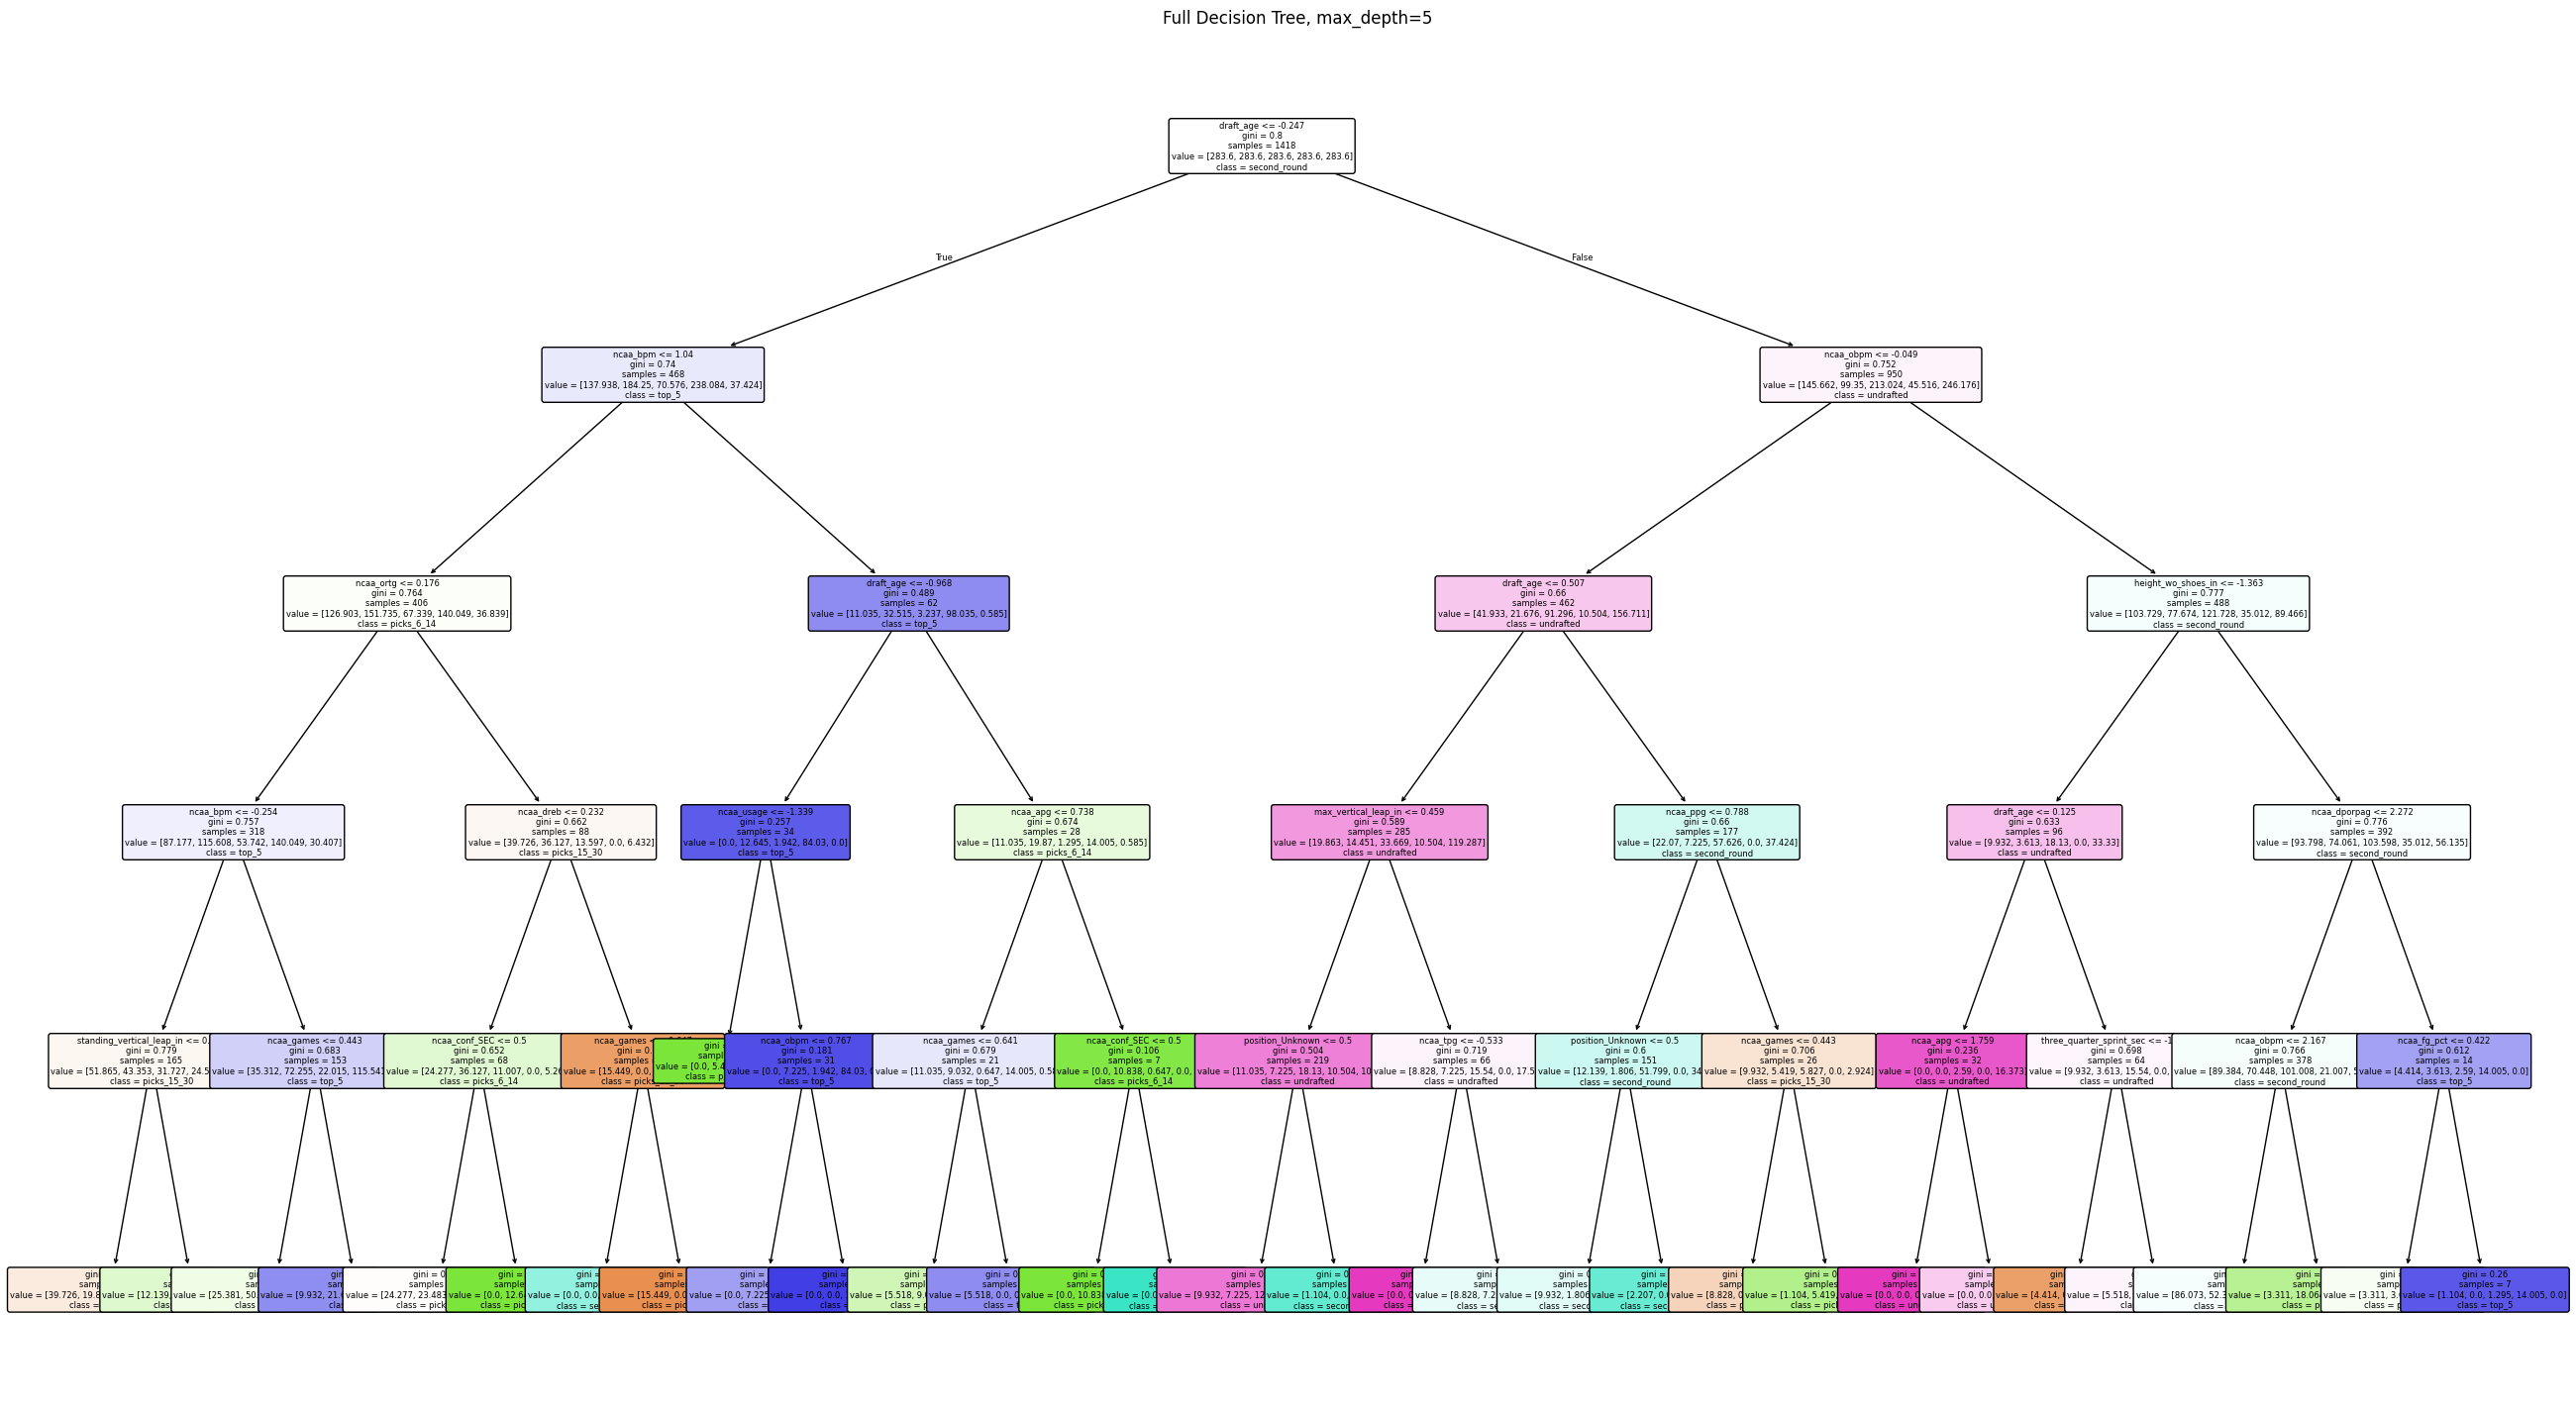

In [76]:
from sklearn.tree import plot_tree

plt.figure(figsize=(32, 18))

plot_tree(
    decision_tree,
    feature_names=X_train.columns,
    class_names=decision_tree.classes_,
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title(f"Full Decision Tree, max_depth={best_depth}")
plt.savefig("decision_tree_full.png", dpi=300, bbox_inches="tight")
plt.show()

As we can see, age is a key metric in the very first category. The next category is based on ncaa_bpm - the “plus-minus” metric represents the difference between the number of points a team scores with a player on the court and without that player on the court. 

In the next step with RF, we’ll see which features are most important. 

### Modeling Step 7 - Random Forest

Similarly, let’s test a few different values for hyperparameters and choose the best set:

In [85]:
from itertools import product
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [5, 8, 10, 12, None],
    "min_samples_leaf": [1, 3, 5, 7, 10],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_tuning_results = []

for n_estimators, max_depth, min_samples_leaf, max_features, class_weight in product(
    rf_grid["n_estimators"],
    rf_grid["max_depth"],
    rf_grid["min_samples_leaf"],
    rf_grid["max_features"],
    rf_grid["class_weight"]
):
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    
    rf_tuning_results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "max_features": max_features,
        "class_weight": class_weight,
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred)
    })

rf_tuning_results_df = (
    pd.DataFrame(rf_tuning_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

rf_results_df.head(10)

,n_estimators,max_depth,min_samples_leaf,macro_f1,balanced_accuracy
0,500,8.0,3,0.519534,0.525639
1,300,8.0,3,0.511722,0.516899
2,500,8.0,5,0.510590,0.526255
3,800,10.0,3,0.503387,0.506146
4,300,8.0,5,0.502742,0.513741
5,500,10.0,3,0.502269,0.507459
6,500,8.0,7,0.501400,0.523321
7,800,8.0,3,0.500222,0.505414
8,500,10.0,7,0.498782,0.519247
9,800,10.0,7,0.498244,0.517570


In [86]:
best_rf_cfg = rf_tuning_results_df.iloc[0]

best_max_depth = best_rf_cfg["max_depth"]
best_max_depth = None if pd.isna(best_max_depth) else int(best_max_depth)

best_rf = RandomForestClassifier(
    n_estimators=int(best_rf_cfg["n_estimators"]),
    max_depth=best_max_depth,
    min_samples_leaf=int(best_rf_cfg["min_samples_leaf"]),
    max_features=best_rf_cfg["max_features"],
    class_weight=best_rf_cfg["class_weight"],
    random_state=42,
    n_jobs=-1
)

best_rf_results, y_val_pred_best_rf = evaluate_model(
    (
        f"Random Forest "
        f"n_estimators={int(best_rf_cfg['n_estimators'])}, "
        f"max_depth={best_max_depth}, "
        f"min_samples_leaf={int(best_rf_cfg['min_samples_leaf'])}, "
        f"max_features={best_rf_cfg['max_features']}, "
        f"class_weight={best_rf_cfg['class_weight']}"
    ),
    best_rf,
    X_train,
    y_train,
    X_val,
    y_val
)

Random Forest n_estimators=800, max_depth=10, min_samples_leaf=1, max_features=0.5, class_weight=balanced_subsample
Macro F1: 0.5297
Balanced accuracy: 0.5217

Classification report:
              precision    recall  f1-score   support

       top_5       0.58      0.55      0.56        20
  picks_6_14       0.54      0.36      0.43        39
 picks_15_30       0.44      0.42      0.43        64
second_round       0.56      0.49      0.52       110
   undrafted       0.63      0.79      0.70       122

    accuracy                           0.57       355
   macro avg       0.55      0.52      0.53       355
weighted avg       0.56      0.57      0.56       355



,pred_top_5,pred_picks_6_14,pred_picks_15_30,pred_second_round,pred_undrafted
true_top_5,11,4,3,0,2
true_picks_6_14,4,14,12,5,4
true_picks_15_30,2,6,27,16,13
true_second_round,1,2,16,54,37
true_undrafted,1,0,4,21,96


In [93]:
model_results.append(best_rf_results)
pd.DataFrame(model_results)

,model,macro_f1,balanced_accuracy
0,Dummy Classifier,0.102300,0.200000
1,Logistic Regression,0.437420,0.483479
2,Gaussian Naive Bayes,0.079883,0.202131
3,Linear SVM,0.389849,0.448348
4,Decision Tree max_depth=5,0.424481,0.425149
5,"Random Forest n_estimators=800, max_depth=10, ...",0.529689,0.521729


Random Forest is the strongest model for now in the validation experiment. 
This model achieved the highest macro F1-score among all tested models = 0.5297, and balanced accuracy = 0.5217. 

Compared with the single Decision Tree, Random Forest improved overall stability and produced better balanced performance across draft outcome groups. The model performed especially well on the undrafted class, with recall equal to 0.81, and also achieved the best top_5 F1-score among the tested models.

At the same time, the confusion matrix shows that the task remains difficult. Most errors happen between second_round and undrafted, and between the middle first-round groups. This is expected because exact draft position depends not only on player statistics, but also on team needs and other factors not fully represented in the dataset.

Random Forest was selected as the best candidate model for further evaluation and interpretation.

# Phase 6 - Evaluation

In the previous stage, we determined that RandomForest performed best among all the models we tested. Now we will train the selected model and make predictions on the data of interest to us. 

As mentioned earlier, the results of the 2026 draft were not known at the time of the project. For this reason, I am dividing this stage into two parts. We will split the data into three parts: 2000-2024, 2025, and 2026. Initially, we will use 2025 as the actual test dataset. After training the model on the 2000-2024 data, we will evaluate its effectiveness for predicting 2025, visualize the prediction, and compare it with predictions from other experts. 

In the second part, we will include the 2025 draft as test data and use 2026 as the test. Based on the model’s output, we will formulate our prediction, compare it with predictions from other experts (but not yet with actual results), and then deploy the model so that in the future we can compare actual results with our predictions. 

### Evaluation Step 1 - Prediction for 2025 test data

First, let's split the data by year into training and test sets:

In [102]:
train_2000_2024_mask = model_data["draft_year"].between(2000, 2024)
test_2025_mask = model_data["draft_year"] == 2025

X_train_2024_raw = X_clean.loc[train_2000_2024_mask].copy()
y_train_2024 = y.loc[X_train_2024_raw.index].copy()

X_test_2025_raw = X_clean.loc[test_2025_mask].copy()
y_test_2025 = y.loc[X_test_2025_raw.index].copy()

print("Train 2000–2024:", X_train_2024_raw.shape)
print("Test 2025:", X_test_2025_raw.shape)

Train 2000–2024: (1706, 35)
Test 2025: (67, 35)


Let’s repeat the same preprocessing we did in the previous step for the new data separation (since we’re using median replacement)

In [103]:
X_train_2024, X_test_2025 = preprocess(
    X_train_2024_raw,
    X_test_2025_raw
)

print("Processed train 2000–2024:", X_train_2024.shape)
print("Processed test 2025:", X_test_2025.shape)

print("\nMissing values:")
print("Train:", X_train_2024.isna().sum().sum())
print("Test 2025:", X_test_2025.isna().sum().sum())

Processed train 2000–2024: (1706, 100)
Processed test 2025: (67, 100)

Missing values:
Train: 0
Test 2025: 0


Let's save metadata for interpreting 2025 predictions

In [98]:
metadata_2025 = model_data.loc[
    X_test_2025_raw.index,
    ["name", "draft_year", "overall_pick", "draft_group", "position", "organization"]
].copy()

metadata_2025.sort_values("overall_pick").head(10)

,name,draft_year,overall_pick,draft_group,position,organization
2183,cooper flagg,2025,1.0,top_5,SF-PF,Duke
2184,dylan harper,2025,2.0,top_5,PG-SG,Rutgers
2185,vj edgecombe,2025,3.0,top_5,PG-SG,Baylor
2186,kon knueppel,2025,4.0,top_5,PG-SG,Duke
2187,ace bailey,2025,5.0,top_5,SF-PF,Rutgers
2188,tre johnson,2025,6.0,picks_6_14,PG-SG,Texas
2189,jeremiah fears,2025,7.0,picks_6_14,PG-SG,Oklahoma
2190,egor demin,2025,8.0,picks_6_14,PG-SG,Brigham Young
2191,collin murray boyles,2025,9.0,picks_6_14,SF-PF,South Carolina
2192,khaman maluach,2025,10.0,picks_6_14,C,Duke


To select the best parameters for the RF, we will also split the training dataset into a validation and training 

In [104]:
X_rf_train_raw, X_rf_val_raw, y_rf_train, y_rf_val = train_test_split(
    X_train_2024_raw,
    y_train_2024,
    test_size=0.2,
    random_state=42,
    stratify=y_train_2024
)

X_rf_train, X_rf_val = preprocess(X_rf_train_raw, X_rf_val_raw)

print("RF tuning train:", X_rf_train.shape)
print("RF tuning validation:", X_rf_val.shape)

RF tuning train: (1364, 98)
RF tuning validation: (342, 98)


And repeat Random Forest hyperparameter tuning for this splitting:

In [106]:
rf_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [5, 8, 10, 12, None],
    "min_samples_leaf": [1, 3, 5, 7, 10],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": ["balanced", "balanced_subsample"]
}

rf_tuning_results = []

for n_estimators, max_depth, min_samples_leaf, max_features, class_weight in product(
    rf_grid["n_estimators"],
    rf_grid["max_depth"],
    rf_grid["min_samples_leaf"],
    rf_grid["max_features"],
    rf_grid["class_weight"]
):
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_rf_train, y_rf_train)
    y_rf_val_pred = rf.predict(X_rf_val)
    
    rf_tuning_results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "max_features": max_features,
        "class_weight": class_weight,
        "macro_f1": f1_score(y_rf_val, y_rf_val_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_rf_val, y_rf_val_pred)
    })

rf_tuning_results_df = (
    pd.DataFrame(rf_tuning_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

rf_tuning_results_df.head(10)

,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,macro_f1,balanced_accuracy
0,300,12.0,1,sqrt,balanced,0.489437,0.470828
1,800,NaN,1,sqrt,balanced_subsample,0.469833,0.448703
2,500,12.0,1,log2,balanced,0.469323,0.447522
3,300,12.0,7,sqrt,balanced,0.468712,0.482705
4,300,10.0,5,sqrt,balanced_subsample,0.466396,0.474463
5,300,8.0,1,log2,balanced,0.464753,0.457798
6,300,12.0,1,log2,balanced,0.463665,0.442614
7,300,NaN,7,sqrt,balanced,0.461466,0.473804
8,300,NaN,3,log2,balanced_subsample,0.461271,0.453384
9,300,NaN,1,sqrt,balanced_subsample,0.460214,0.441854


The first Random Forest tuning inside the 2000–2024 period produced slightly lower scores than the earlier random validation experiment. This is expected because the training period is now smaller and the validation split is different.

To make the hyperparameter choice more stable, the best configurations from the initial grid search are further evaluated using stratified cross-validation.

In [108]:
from sklearn.model_selection import StratifiedKFold

top_configs = rf_tuning_results_df.head(20).copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_results = []

for config_id, cfg in top_configs.iterrows():
    fold_scores = []
    
    max_depth = cfg["max_depth"]
    max_depth = None if pd.isna(max_depth) else int(max_depth)
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_2024_raw, y_train_2024), start=1):
        X_fold_train_raw = X_train_2024_raw.iloc[train_idx]
        X_fold_val_raw = X_train_2024_raw.iloc[val_idx]
        y_fold_train = y_train_2024.iloc[train_idx]
        y_fold_val = y_train_2024.iloc[val_idx]
        
        X_fold_train, X_fold_val = preprocess(X_fold_train_raw, X_fold_val_raw)
        
        rf = RandomForestClassifier(
            n_estimators=int(cfg["n_estimators"]),
            max_depth=max_depth,
            min_samples_leaf=int(cfg["min_samples_leaf"]),
            max_features=cfg["max_features"],
            class_weight=cfg["class_weight"],
            random_state=42,
            n_jobs=-1
        )
        
        rf.fit(X_fold_train, y_fold_train)
        y_fold_pred = rf.predict(X_fold_val)
        
        fold_scores.append({
            "macro_f1": f1_score(y_fold_val, y_fold_pred, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(y_fold_val, y_fold_pred)
        })
    
    fold_scores_df = pd.DataFrame(fold_scores)
    
    rf_cv_results.append({
        "n_estimators": int(cfg["n_estimators"]),
        "max_depth": max_depth,
        "min_samples_leaf": int(cfg["min_samples_leaf"]),
        "max_features": cfg["max_features"],
        "class_weight": cfg["class_weight"],
        "mean_macro_f1": fold_scores_df["macro_f1"].mean(),
        "std_macro_f1": fold_scores_df["macro_f1"].std(),
        "mean_balanced_accuracy": fold_scores_df["balanced_accuracy"].mean(),
        "std_balanced_accuracy": fold_scores_df["balanced_accuracy"].std()
    })

rf_cv_results_df = (
    pd.DataFrame(rf_cv_results)
    .sort_values("mean_macro_f1", ascending=False)
    .reset_index(drop=True)
)

rf_cv_results_df.head(10)

,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,mean_macro_f1,std_macro_f1,mean_balanced_accuracy,std_balanced_accuracy
0,300,NaN,5,sqrt,balanced_subsample,0.424468,0.013648,0.431259,0.014387
1,300,NaN,3,log2,balanced_subsample,0.420583,0.018839,0.416057,0.018281
2,300,NaN,7,sqrt,balanced,0.419440,0.016319,0.432724,0.022126
3,300,8.0,5,sqrt,balanced_subsample,0.417549,0.011413,0.430264,0.009763
4,300,10.0,5,sqrt,balanced_subsample,0.416642,0.011576,0.427445,0.007324
5,500,10.0,1,sqrt,balanced_subsample,0.416101,0.019542,0.405762,0.015063
6,300,8.0,1,log2,balanced,0.413717,0.012828,0.410877,0.009054
7,300,10.0,3,sqrt,balanced_subsample,0.412364,0.011906,0.416508,0.014450
8,500,8.0,5,log2,balanced,0.410618,0.021107,0.425172,0.026521
9,500,10.0,1,log2,balanced,0.410346,0.030735,0.400237,0.024713


The cross-validation results are lower than the previous single validation split results, which suggests that Random Forest performance is sensitive to the exact train-validation split. For this reason, the final Random Forest configuration is selected based on the mean macro F1-score across folds rather than on a single validation result.

The best cross-validated configuration is then trained on the full 2000–2024 dataset and evaluated once on the held-out 2025 draft class.

In [112]:
best_cv_cfg = rf_cv_results_df.iloc[0]

best_cv_max_depth = best_cv_cfg["max_depth"]
best_cv_max_depth = None if pd.isna(best_cv_max_depth) else int(best_cv_max_depth)

final_rf_2025 = RandomForestClassifier(
    n_estimators=int(best_cv_cfg["n_estimators"]),
    max_depth=best_cv_max_depth,
    min_samples_leaf=int(best_cv_cfg["min_samples_leaf"]),
    max_features=best_cv_cfg["max_features"],
    class_weight=best_cv_cfg["class_weight"],
    random_state=42,
    n_jobs=-1
)

final_rf_2025.fit(X_train_2024, y_train_2024)

y_pred_2025 = final_rf_2025.predict(X_test_2025)
y_proba_2025 = final_rf_2025.predict_proba(X_test_2025)

print(
    f"Random Forest 2025 test: "
    f"n_estimators={int(best_cv_cfg['n_estimators'])}, "
    f"max_depth={best_cv_max_depth}, "
    f"min_samples_leaf={int(best_cv_cfg['min_samples_leaf'])}, "
    f"max_features={best_cv_cfg['max_features']}, "
    f"class_weight={best_cv_cfg['class_weight']}"
)

print("Macro F1:", round(f1_score(y_test_2025, y_pred_2025, average="macro"), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test_2025, y_pred_2025), 4))

print("\nClassification report:")
print(classification_report(
    y_test_2025,
    y_pred_2025,
    labels=group_order,
    zero_division=0
))

cm_2025 = pd.DataFrame(
    confusion_matrix(y_test_2025, y_pred_2025, labels=group_order),
    index=[f"true_{c}" for c in group_order],
    columns=[f"pred_{c}" for c in group_order]
)

cm_2025

Random Forest 2025 test: n_estimators=300, max_depth=None, min_samples_leaf=5, max_features=sqrt, class_weight=balanced_subsample
Macro F1: 0.634
Balanced accuracy: 0.6278

Classification report:
              precision    recall  f1-score   support

       top_5       0.75      0.60      0.67         5
  picks_6_14       0.40      0.50      0.44         8
 picks_15_30       0.50      0.45      0.48        11
second_round       0.72      0.86      0.78        21
   undrafted       0.89      0.73      0.80        22

    accuracy                           0.69        67
   macro avg       0.65      0.63      0.63        67
weighted avg       0.70      0.69      0.69        67



,pred_top_5,pred_picks_6_14,pred_picks_15_30,pred_second_round,pred_undrafted
true_top_5,3,1,1,0,0
true_picks_6_14,1,4,2,1,0
true_picks_15_30,0,4,5,1,1
true_second_round,0,1,1,18,1
true_undrafted,0,0,1,5,16


The model achieved a macro F1-score of 0.634 and balanced accuracy of 0.628. This is a strong result compared with the previous validation experiments!

In [117]:
pred_2025_df = metadata_2025.copy()
pred_2025_df["predicted_group"] = y_pred_2025
pred_2025_df["correct"] = pred_2025_df["draft_group"] == pred_2025_df["predicted_group"]

pred_2025_df.sort_values(["overall_pick"]).reset_index(drop=True).head(30)

,name,draft_year,overall_pick,draft_group,position,organization,predicted_group,correct
0,cooper flagg,2025,1.0,top_5,SF-PF,Duke,top_5,True
1,dylan harper,2025,2.0,top_5,PG-SG,Rutgers,top_5,True
2,vj edgecombe,2025,3.0,top_5,PG-SG,Baylor,top_5,True
3,kon knueppel,2025,4.0,top_5,PG-SG,Duke,picks_6_14,False
4,ace bailey,2025,5.0,top_5,SF-PF,Rutgers,picks_15_30,False
5,tre johnson,2025,6.0,picks_6_14,PG-SG,Texas,picks_6_14,True
6,jeremiah fears,2025,7.0,picks_6_14,PG-SG,Oklahoma,picks_15_30,False
7,egor demin,2025,8.0,picks_6_14,PG-SG,Brigham Young,picks_15_30,False
8,collin murray boyles,2025,9.0,picks_6_14,SF-PF,South Carolina,top_5,False
9,khaman maluach,2025,10.0,picks_6_14,C,Duke,picks_6_14,True


The model correctly identified three of the five top_5 players and performed well on the second_round and undrafted classes. Most errors still occurred between neighboring draft outcome groups, such as picks_6_14 versus picks_15_30, or second_round versus undrafted.

However, the 2025 test set is relatively small, especially for the top draft groups, so these results should be interpreted cautiously.

Now let’s visualize the predictions we have

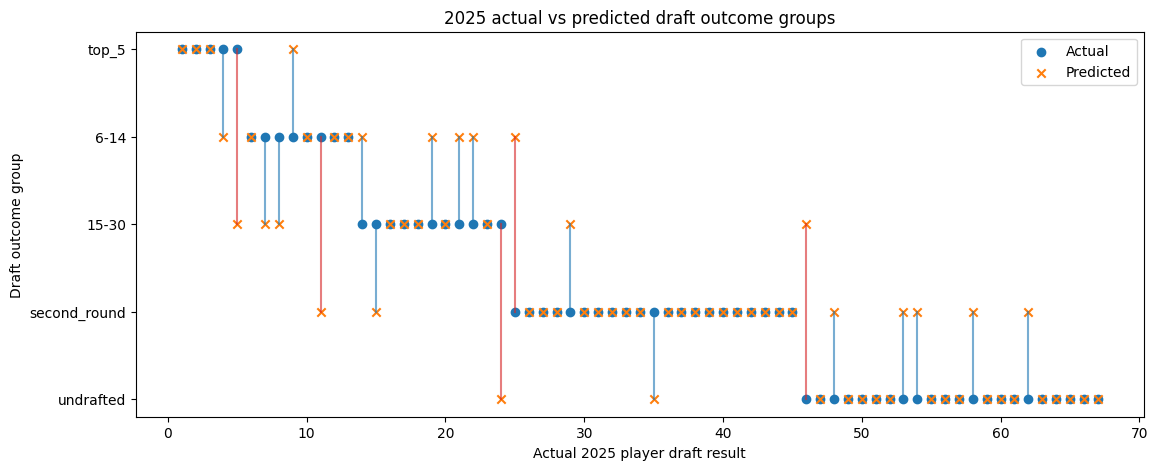

In [121]:
group_to_rank = {
    "top_5": 1,
    "picks_6_14": 2,
    "picks_15_30": 3,
    "second_round": 4,
    "undrafted": 5
}
rank_to_label = {
    1: "top_5",
    2: "6-14",
    3: "15-30",
    4: "second_round",
    5: "undrafted"
}

pred_2025_viz = pred_2025_df.copy()
pred_2025_viz["actual_rank"] = pred_2025_viz["draft_group"].map(group_to_rank)
pred_2025_viz["predicted_rank"] = pred_2025_viz["predicted_group"].map(group_to_rank)
pred_2025_viz["rank_error"] = pred_2025_viz["predicted_rank"] - pred_2025_viz["actual_rank"]
pred_2025_viz["abs_rank_error"] = pred_2025_viz["rank_error"].abs()

plot_df = pred_2025_viz.sort_values(["overall_pick", "name"]).reset_index(drop=True)
plot_df["player_order"] = range(1, len(plot_df) + 1)

line_colors = {
    1: "tab:blue",
    2: "tab:red"
}

plt.figure(figsize=(13, 5))
plt.scatter(plot_df["player_order"], plot_df["actual_rank"], label="Actual")
plt.scatter(plot_df["player_order"], plot_df["predicted_rank"], marker="x", label="Predicted")

for _, row in plot_df.iterrows():
    err = row["abs_rank_error"]
    
    if err > 0:
        plt.plot(
            [row["player_order"], row["player_order"]],
            [row["actual_rank"], row["predicted_rank"]],
            color=line_colors.get(err, "gray"),
            alpha=0.6,
            linewidth=1.5
        )

plt.yticks(list(rank_to_label.keys()), list(rank_to_label.values()))
plt.gca().invert_yaxis()
plt.xlabel("Actual 2025 player draft result")
plt.ylabel("Draft outcome group")
plt.title("2025 actual vs predicted draft outcome groups")
plt.legend()
plt.show()

And let's see which features turned out to be the most important

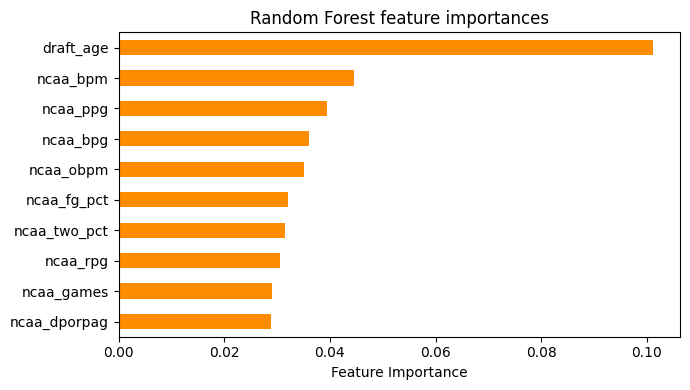

In [132]:
importances_rf = pd.Series(final_rf_2025.feature_importances_, index=X_train_2024.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances_rf.tail(10).plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest feature importances")
fig.tight_layout()

We can see that this includes age at the time of entering the draft, average plus-minus, and average points per game. 

To further demonstrate the strength of our prediction, let’s create a PCA plot, visualize the structure of the player feature space.

In [147]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_train_2024_pca = pca.fit_transform(X_train_2024)
X_test_2025_pca = pca.transform(X_test_2025)

print("Explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum().round(3))

Explained variance by PC1 and PC2:
[0.28310056 0.12264763]
Total explained variance: 0.406


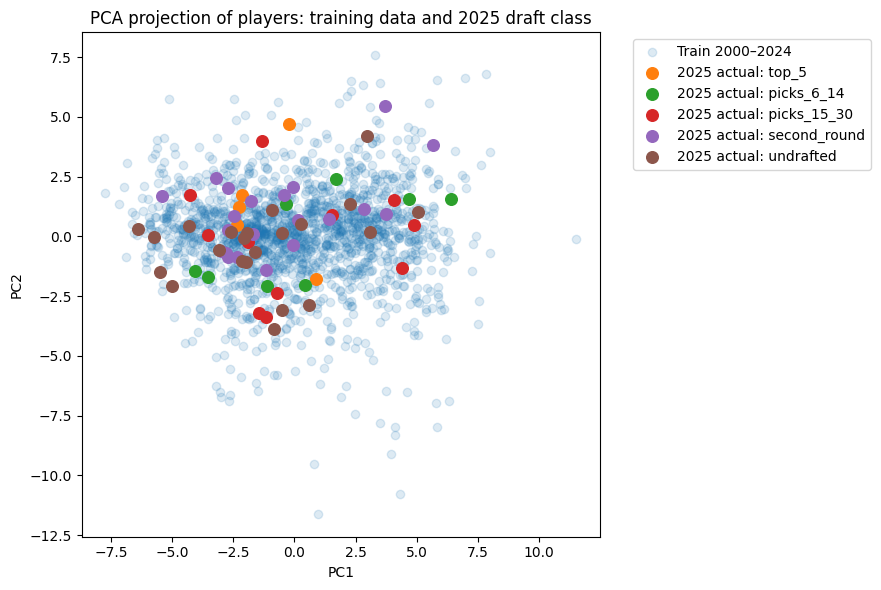

In [148]:
pca_train_df = pd.DataFrame({
    "PC1": X_train_2024_pca[:, 0],
    "PC2": X_train_2024_pca[:, 1],
    "draft_group": y_train_2024.values,
    "dataset": "train_2000_2024"
}, index=X_train_2024.index)

pca_2025_df = pred_2025_df.copy()
pca_2025_df["PC1"] = X_test_2025_pca[:, 0]
pca_2025_df["PC2"] = X_test_2025_pca[:, 1]
pca_2025_df["dataset"] = "test_2025"

plt.figure(figsize=(9, 6))

plt.scatter(
    pca_train_df["PC1"],
    pca_train_df["PC2"],
    alpha=0.15,
    label="Train 2000–2024"
)

for group in group_order:
    group_df = pca_2025_df[pca_2025_df["draft_group"] == group]
    plt.scatter(
        group_df["PC1"],
        group_df["PC2"],
        label=f"2025 actual: {group}",
        s=70
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of players: training data and 2025 draft class")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Unfortunately, the first two principal components explained about 40.6% of the total variance, which is enough for a rough visualization but not enough to fully represent the original feature space. The actual draft outcome groups for 2025 players strongly overlap in the PCA space.

We could try performing clustering using K-means to see if there is any overlap between the actual groups and the resulting clusters. However, it seems unlikely that this would yield meaningful results, given the high complexity of the data. 

For the final visualization, let’s save the confusion matrix as a heatmap. 

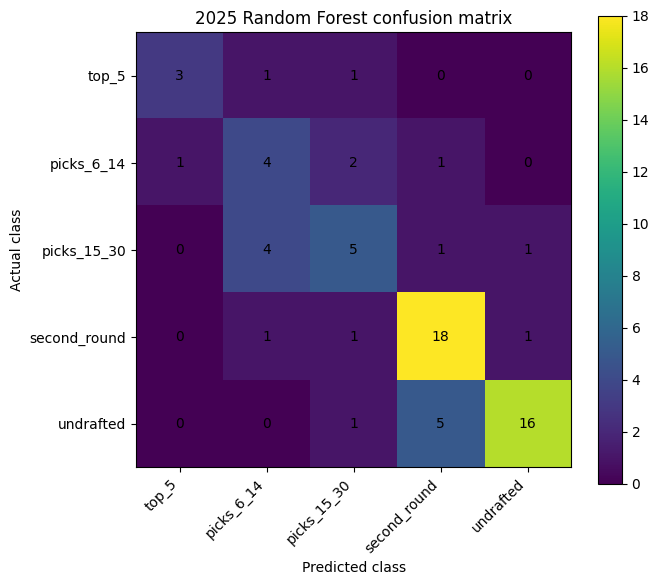

In [154]:
cm_2025_values = confusion_matrix(
    y_test_2025,
    y_pred_2025,
    labels=group_order
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_2025_values)

ax.set_xticks(np.arange(len(group_order)))
ax.set_yticks(np.arange(len(group_order)))
ax.set_xticklabels(group_order, rotation=45, ha="right")
ax.set_yticklabels(group_order)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("2025 Random Forest confusion matrix")

for i in range(len(group_order)):
    for j in range(len(group_order)):
        ax.text(
            j, i,
            cm_2025_values[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

### Evaluation Step 2 - Comparison with experts predictions for 2025 test data

To put the model performance into context, our 2025 predictions are compared with an expert mock draft baseline (ESPN, huge US sport media).

An expert mock draft is not a perfect ground truth, but it represents informed human expectations before the draft. Comparing the model with a mock draft helps evaluate whether the machine learning model performs reasonably in a difficult prediction task.

Source: https://www.espn.com/nba/story/_/id/45559441/2025-nba-mock-draft-latest-first-second-round-predictions-all-59-picks

The data was manually compiled into a dataset

In [164]:
import re
import unicodedata

espn_mock_2025 = pd.read_csv("data/external/espn_mock_draft_2025.csv")

def normalize_name(name):
    if pd.isna(name):
        return np.nan
    name = str(name).lower()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(ch for ch in name if not unicodedata.combining(ch))
    name = re.sub(r"[^a-z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    name = re.sub(r"\b(jr|sr|ii|iii|iv|v)\b$", "", name).strip()
    return name

pred_2025_tmp = pred_2025_df.copy()
pred_2025_tmp["name_norm"] = pred_2025_tmp["name"].apply(normalize_name)
espn_mock_tmp = espn_mock_2025.copy()
espn_mock_tmp["name_norm"] = espn_mock_tmp["name"].apply(normalize_name)

comparison_2025_df = pred_2025_tmp.merge(
    espn_mock_tmp[["name_norm", "mock_group"]],
    on="name_norm",
    how="left"
)

# If player is not present in ESPN mock top-59, assume that ESPN predicts him as undrafted
comparison_2025_df["mock_group"] = comparison_2025_df["mock_group"].fillna("undrafted")

comparison_2025_df = comparison_2025_df[[
    "name",
    "overall_pick",
    "draft_group",
    "predicted_group",
    "mock_group"
]].rename(columns={
    "overall_pick": "actual_pick",
    "draft_group": "actual_group",
    "predicted_group": "model_group",
    "mock_group": "espn_group"
})

comparison_2025_df.sort_values(["actual_pick", "name"]).reset_index(drop=True)

,name,actual_pick,actual_group,model_group,espn_group
0,cooper flagg,1.0,top_5,top_5,top_5
1,dylan harper,2.0,top_5,top_5,top_5
2,vj edgecombe,3.0,top_5,top_5,top_5
3,kon knueppel,4.0,top_5,picks_6_14,top_5
4,ace bailey,5.0,top_5,picks_15_30,picks_6_14
...,...,...,...,...,...
62,ryan nembhard,999.0,undrafted,undrafted,second_round
63,tahaad pettiford,999.0,undrafted,undrafted,undrafted
64,tamar bates,999.0,undrafted,undrafted,undrafted
65,vladislav goldin,999.0,undrafted,undrafted,second_round


Now, keeping in mind that our metrics showed an accuracy of around 0.69, let’s calculate the same metrics for the “model” developed by the experts. 

Let’s also compare how similar our predictions are to the experts’ predictions. 

In [170]:
print("Model vs actual")
print(classification_report(
    comparison_2025_df["actual_group"],
    comparison_2025_df["model_group"],
    labels=group_order,
    zero_division=0
))

print("ESPN mock vs actual")
print(classification_report(
    comparison_2025_df["actual_group"],
    comparison_2025_df["espn_group"],
    labels=group_order,
    zero_division=0
))

print("Model vs ESPN mock")
print(classification_report(
    comparison_2025_df["model_group"],
    comparison_2025_df["espn_group"],
    labels=group_order,
    zero_division=0
))

Model vs actual
              precision    recall  f1-score   support

       top_5       0.75      0.60      0.67         5
  picks_6_14       0.40      0.50      0.44         8
 picks_15_30       0.50      0.45      0.48        11
second_round       0.72      0.86      0.78        21
   undrafted       0.89      0.73      0.80        22

    accuracy                           0.69        67
   macro avg       0.65      0.63      0.63        67
weighted avg       0.70      0.69      0.69        67

ESPN mock vs actual
              precision    recall  f1-score   support

       top_5       0.80      0.80      0.80         5
  picks_6_14       0.71      0.62      0.67         8
 picks_15_30       0.62      0.73      0.67        11
second_round       0.70      0.67      0.68        21
   undrafted       0.82      0.82      0.82        22

    accuracy                           0.73        67
   macro avg       0.73      0.73      0.73        67
weighted avg       0.73      0.73      0.

As expected, the expert mock draft performed better than the machine learning model. ESPN achieved a macro F1-score of 0.73, while the Random Forest model achieved a macro F1-score of 0.63. ESPN also had slightly higher overall accuracy.

However, the model performance was still reasonably close to the expert baseline. This is notable because the model uses only structured historical player data, while expert mock drafts can incorporate scouting reports, team needs, interviews, workouts, rumors, and insider information.

The comparison between the model predictions and the ESPN mock draft also shows that the two approaches do not agree. This suggests that the model captures a different statistical view of the draft.

Let's save the final table for the presentation:

In [172]:
method_comparison = pd.DataFrame([
    {
        "method": "Random Forest model",
        "accuracy": accuracy_score(
            comparison_2025_df["actual_group"],
            comparison_2025_df["model_group"]
        ),
        "macro_f1": f1_score(
            comparison_2025_df["actual_group"],
            comparison_2025_df["model_group"],
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            comparison_2025_df["actual_group"],
            comparison_2025_df["model_group"]
        )
    },
    {
        "method": "ESPN mock draft",
        "accuracy": accuracy_score(
            comparison_2025_df["actual_group"],
            comparison_2025_df["espn_group"]
        ),
        "macro_f1": f1_score(
            comparison_2025_df["actual_group"],
            comparison_2025_df["espn_group"],
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            comparison_2025_df["actual_group"],
            comparison_2025_df["espn_group"]
        )
    },
    {
        "method": "Model vs ESPN agreement",
        "accuracy": accuracy_score(
            comparison_2025_df["espn_group"],
            comparison_2025_df["model_group"]
        ),
        "macro_f1": f1_score(
            comparison_2025_df["espn_group"],
            comparison_2025_df["model_group"],
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            comparison_2025_df["espn_group"],
            comparison_2025_df["model_group"]
        )
    }
])

method_comparison.round(3)

,method,accuracy,macro_f1,balanced_accuracy
0,Random Forest model,0.687,0.634,0.628
1,ESPN mock draft,0.731,0.727,0.727
2,Model vs ESPN agreement,0.507,0.492,0.491


And let’s compare correct predictions and errors in the same way, but this time for two predictive models and the true values:

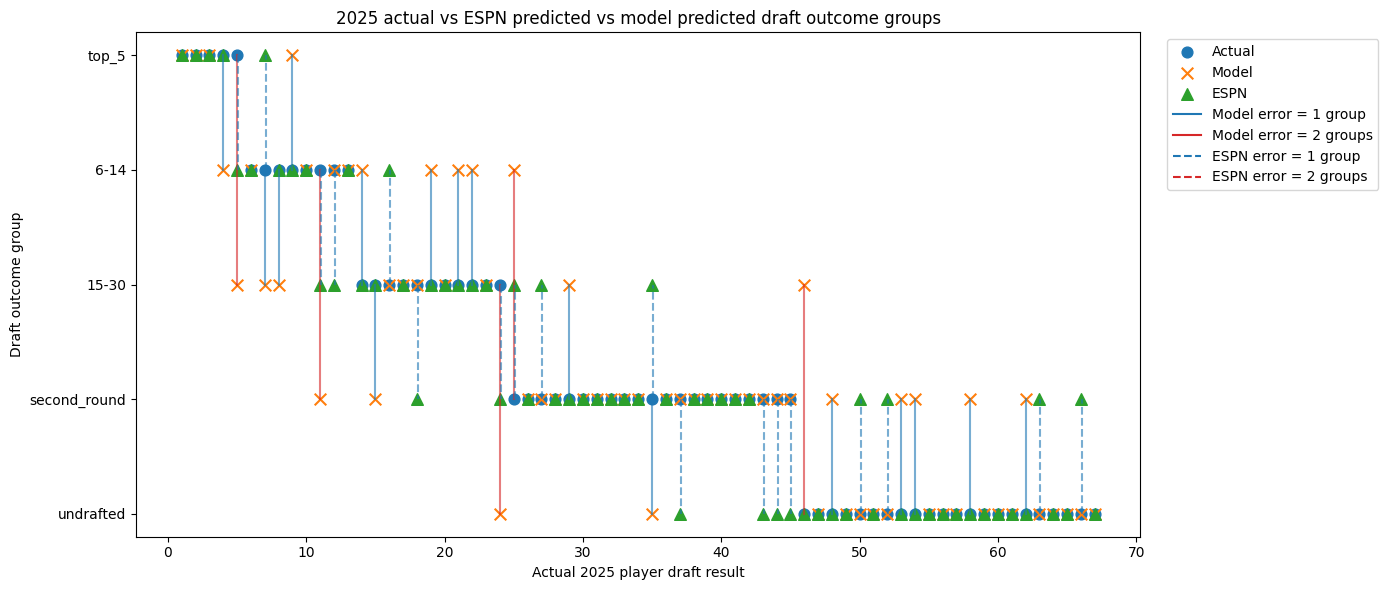

In [181]:
plot_df = comparison_2025_df.copy()
plot_df["actual_rank"] = plot_df["actual_group"].map(group_to_rank)
plot_df["model_rank"] = plot_df["model_group"].map(group_to_rank)
plot_df["espn_rank"] = plot_df["espn_group"].map(group_to_rank)

plot_df["model_abs_error"] = (plot_df["model_rank"] - plot_df["actual_rank"]).abs()
plot_df["espn_abs_error"] = (plot_df["espn_rank"] - plot_df["actual_rank"]).abs()

plot_df = plot_df.sort_values(["actual_pick", "name"]).reset_index(drop=True)
plot_df["player_order"] = range(1, len(plot_df) + 1)

line_colors = {
    1: "tab:blue",
    2: "tab:red"
}

plt.figure(figsize=(14, 6))

plt.scatter(
    plot_df["player_order"],
    plot_df["actual_rank"],
    label="Actual",
    s=60
)

plt.scatter(
    plot_df["player_order"],
    plot_df["model_rank"],
    marker="x",
    label="Model",
    s=70
)

plt.scatter(
    plot_df["player_order"],
    plot_df["espn_rank"],
    marker="^",
    label="ESPN",
    s=70
)

for _, row in plot_df.iterrows():
    if row["model_abs_error"] > 0:
        plt.plot(
            [row["player_order"], row["player_order"]],
            [row["actual_rank"], row["model_rank"]],
            color=line_colors.get(row["model_abs_error"], "gray"),
            alpha=0.6,
            linewidth=1.5
        )

for _, row in plot_df.iterrows():
    if row["espn_abs_error"] > 0:
        plt.plot(
            [row["player_order"] + 0.08, row["player_order"] + 0.08],
            [row["actual_rank"], row["espn_rank"]],
            color=line_colors.get(row["espn_abs_error"], "gray"),
            alpha=0.6,
            linewidth=1.5,
            linestyle="--"
        )

plt.yticks(list(rank_to_label.keys()), list(rank_to_label.values()))
plt.gca().invert_yaxis()

plt.xlabel("Actual 2025 player draft result")
plt.ylabel("Draft outcome group")
plt.title("2025 actual vs ESPN predicted vs model predicted draft outcome groups")

plt.plot([], [], color="tab:blue", label="Model error = 1 group")
plt.plot([], [], color="tab:red", label="Model error = 2 groups")
plt.plot([], [], color="tab:blue", linestyle="--", label="ESPN error = 1 group")
plt.plot([], [], color="tab:red", linestyle="--", label="ESPN error = 2 groups")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The player-level comparison shows that ESPN performed better overall, especially in the top and middle parts of the draft. This is expected because expert mock drafts can include information that is not present in the structured dataset, such as team needs, interviews, rumors, and insider reporting.

For example, ESPN correctly kept Kon Knueppel (number 4) in the top_5, while the model moved him down to picks_6_14. In the case of Ace Bailey (number 5), both ESPN and the model predicted a lower group than his actual result, but ESPN was closer.

However, the Random Forest model performed well in parts of the second round. Several players who were not included in ESPN's mock draft, such as Brooks Barnhizer, Will Richard, Max Shulga, and Jahmai Mashack, were correctly predicted by the model as second_round players. This suggests that the model can identify statistical profiles of less publicized prospects who may be missed by expert mock drafts.

Another interesting observation is that there were no identical wrong predictions between the model and ESPN. 

At the same time, the model made several larger errors by two draft groups, while ESPN did not. This indicates that the expert mock draft was better calibrated, especially for highly discussed first-round prospects. Overall, the comparison supports the idea that the model is informative, but expert predictions still benefit from contextual information that is not available in the dataset.

### Evaluation Step 3 - Prediction for 2026 test data

The previous result can be considered a final evaluation and comparison of the model. Since there are no correct answers available yet for the 2026 data, this section is provided as a supplementary. 

No accuracy, F1-score, or confusion matrix can be calculated for 2026 yet. Instead, the model produces prospective draft outcome predictions and class probabilities. These predictions can later be compared with the real 2026 NBA Draft results when they become available. We will also compare our predictions with those of the experts once again. 

Let's repeat the same steps, but with a new splitting by year:

In [182]:
X_train_final_raw = X_clean.copy()
y_train_final = y.loc[X_train_final_raw.index].copy()

X_2026_raw = X_2026_clean.copy()

print("Final training data 2000–2025:", X_train_final_raw.shape)
print("2026 prediction pool:", X_2026_raw.shape)

Final training data 2000–2025: (1773, 35)
2026 prediction pool: (74, 35)


In [183]:
X_train_final, X_2026_final = preprocess(
    X_train_final_raw,
    X_2026_raw
)

print("Processed final training data:", X_train_final.shape)
print("Processed 2026 prediction pool:", X_2026_final.shape)

print("\nMissing values:")
print("Final train:", X_train_final.isna().sum().sum())
print("2026:", X_2026_final.isna().sum().sum())

Processed final training data: (1773, 100)
Processed 2026 prediction pool: (74, 100)

Missing values:
Final train: 0
2026: 0


I’d rather not repeat the hyperparameter tuning for the model right now. The previous set of parameters already proved its worth in a very real-world problem “a year ago.” 

In [185]:
final_rf_2026 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

final_rf_2026.fit(X_train_final, y_train_final)

y_pred_2026 = final_rf_2026.predict(X_2026_final)
y_proba_2026 = final_rf_2026.predict_proba(X_2026_final)

pred_2026_df = prediction_data.loc[
    X_2026_raw.index,
    ["name", "draft_year", "position", "organization"]
].copy()

pred_2026_df["predicted_group"] = y_pred_2026
pred_2026_df["max_probability"] = y_proba_2026.max(axis=1)

for i, cls in enumerate(final_rf_2026.classes_):
    pred_2026_df[f"prob_{cls}"] = y_proba_2026[:, i]

pred_2026_df.sort_values(["predicted_group", "max_probability"], ascending=[True, False]).reset_index(drop=True)

,name,draft_year,position,organization,predicted_group,max_probability,prob_picks_15_30,prob_picks_6_14,prob_second_round,prob_top_5,prob_undrafted
0,matthew able,2026,SG,N.C. State,picks_15_30,0.406259,0.406259,0.183793,0.216036,0.041004,0.152907
1,meleek thomas,2026,SG,Arkansas,picks_15_30,0.331170,0.331170,0.275836,0.165592,0.081169,0.146233
2,zuby ejiofor,2026,C,St. John's,picks_15_30,0.311662,0.311662,0.174262,0.254980,0.130593,0.128503
3,billy richmond,2026,SF,Arkansas,picks_15_30,0.311293,0.311293,0.232376,0.196623,0.134844,0.124863
4,jacob cofie,2026,PF,USC,picks_15_30,0.302953,0.302953,0.235356,0.225088,0.108661,0.127942
...,...,...,...,...,...,...,...,...,...,...,...
69,nick martinelli,2026,PF,Northwestern,undrafted,0.367973,0.155189,0.123999,0.321770,0.031068,0.367973
70,felix okpara,2026,C,Tennessee,undrafted,0.343019,0.209875,0.073891,0.340177,0.033039,0.343019
71,kylan boswell,2026,PG,Illinois,undrafted,0.340080,0.181966,0.094436,0.312880,0.070639,0.340080
72,ugonna onyenso,2026,C,Virginia,undrafted,0.312659,0.151638,0.193390,0.275994,0.066319,0.312659


Just for fun, let’s take a look at a story I know. Yaxel Lendeborg entered the draft last year but wasn’t selected. Experts now project him to be picked around the 10th overall pick. Since we included statistics from last season’s NCAA in our data, even though this is the same player, his numbers as a member of the 2025 draft class and the 2026 draft class are different, and the latter are more impressive. Let’s see if the model actually detects the difference. 

In [188]:
pred_2025_df[pred_2025_df['name'] == 'yaxel lendeborg']

,name,draft_year,overall_pick,draft_group,position,organization,predicted_group,correct
2268,yaxel lendeborg,2025,999.0,undrafted,PF,UAB,undrafted,True


In [189]:
pred_2026_df[pred_2026_df['name'] == 'yaxel lendeborg']

,name,draft_year,position,organization,predicted_group,max_probability,prob_picks_15_30,prob_picks_6_14,prob_second_round,prob_top_5,prob_undrafted
2345,yaxel lendeborg,2026,PF,Michigan,picks_6_14,0.258388,0.199885,0.258388,0.22844,0.114254,0.199033


Yes, we can see that the predictions align with the experts' opinions, whereas last year the model correctly identified him as undrafted player. 

In [192]:
pred_2026_summary = (
    pred_2026_df["predicted_group"]
    .value_counts()
    .reindex(group_order)
    .fillna(0)
    .astype(int)
    .rename_axis("predicted_group")
    .reset_index(name="players")
)

pred_2026_summary

,predicted_group,players
0,top_5,10
1,picks_6_14,13
2,picks_15_30,11
3,second_round,28
4,undrafted,12


It’s immediately clear that we have a lot of players in the top 5—10 in total. This happens because the model predicts each player independently. It does not create a ranked draft board and does not enforce draft-capacity constraints, such as exactly 5 players in the top_5, 9 players in picks_6_14, or 16 players in picks_15_30.

This isn’t ideal, of course, but many have called this year’s draft the “draft of the generation” - the players this year are exceptionally strong, and historical data might even make them seem even stronger. Simply put, this is a clear example of the “draft class effect.” 

To make the 2026 prediction more realistic, an additional post-processing step is applied. Players are ranked using a draft-board score calculated from the predicted class probabilities. The selected score gives the highest weight to top_5 probability, lower weight to later drafted groups, and penalizes undrafted probability.

After ranking players by this score, fixed draft group capacities are applied: the top 5 ranked players are assigned to top_5, the next 9 to picks_6_14, the next 16 to picks_15_30, and the next 30 to second_round. Remaining players are assigned to undrafted.

This post-processed output is not a different machine learning model. It is a draft-board interpretation of the model probabilities under real draft constraints.

In [206]:
pred_2026_ranked = pred_2026_df.copy()

pred_2026_ranked["draft_board_score"] = (
    pred_2026_ranked["prob_top_5"] * 5
    + pred_2026_ranked["prob_picks_6_14"] * 3
    + pred_2026_ranked["prob_picks_15_30"] * 1.5
    + pred_2026_ranked["prob_second_round"] * 0.5
    - pred_2026_ranked["prob_undrafted"] * 1
)

pred_2026_ranked = (
    pred_2026_ranked
    .sort_values("draft_board_score", ascending=False)
    .reset_index(drop=True)
)
pred_2026_ranked["model_rank"] = range(1, len(pred_2026_ranked) + 1)

def assign_ranked_group(rank):
    if rank <= 5:
        return "top_5"
    elif rank <= 14:
        return "picks_6_14"
    elif rank <= 30:
        return "picks_15_30"
    elif rank <= 60:
        return "second_round"
    else:
        return "undrafted"

pred_2026_ranked["ranked_model_group"] = pred_2026_ranked["model_rank"].apply(assign_ranked_group)
pred_2026_ranked[
    [
        "model_rank",
        "name",
        "position",
        "organization",
        "predicted_group",
        "ranked_model_group",
        "draft_board_score",
        "max_probability"
    ]
].head(10)

,model_rank,name,position,organization,predicted_group,ranked_model_group,draft_board_score,max_probability
0,1,cameron boozer,PF,Duke,top_5,top_5,3.954569,0.660983
1,2,caleb wilson,PF,North Carolina,top_5,top_5,3.462778,0.531195
2,3,keaton wagler,PG,Illinois,top_5,top_5,3.407776,0.458024
3,4,kingston flemings,PG,Houston,top_5,top_5,3.263787,0.442225
4,5,allen graves,PF,Santa Clara,top_5,top_5,3.187716,0.432714
5,6,anicet dybantsa,SF,BYU,top_5,picks_6_14,3.080390,0.395599
6,7,darryn peterson,SG,Kansas,picks_6_14,picks_6_14,3.025599,0.357105
7,8,koa peat,PF,Arizona,top_5,picks_6_14,2.879303,0.325536
8,9,hannes steinbach,C,Washington,top_5,picks_6_14,2.843857,0.322807
9,10,darius acuff,PG,Arkansas,picks_6_14,picks_6_14,2.780273,0.401933


Let’s leave our prediction as is—in it, the number of peaks in each group matches reality:

In [217]:
pred_2026_summary_ranked = (
    pred_2026_ranked["ranked_model_group"]
    .value_counts()
    .reindex(group_order)
    .fillna(0)
    .astype(int)
    .rename_axis("ranked_model_group")
    .reset_index(name="players")
)

pred_2026_summary_ranked

,ranked_model_group,players
0,top_5,5
1,picks_6_14,9
2,picks_15_30,16
3,second_round,30
4,undrafted,14


### Evaluation Step 4 - Сomparison with experts predictions for 2026 test data

In [238]:
espn_mock_2026 = pd.read_csv("data/external/espn_mock_draft_2026.csv")

def normalize_name(name):
    if pd.isna(name):
        return np.nan
    name = str(name).lower()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(ch for ch in name if not unicodedata.combining(ch))
    name = re.sub(r"[^a-z0-9 ]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    name = re.sub(r"\b(jr|sr|ii|iii|iv|v)\b$", "", name).strip()
    return name

name_aliases = {
    "aj dybantsa": "anicet dybantsa",
    "nate ament": "nathaniel ament",
    "matt able": "matthew able",
    "chris cenac": "christopher cenac",
    "mikel brown": "christopher brown"
}

def normalize_name_with_alias(name):
    name_norm = normalize_name(name)
    return name_aliases.get(name_norm, name_norm)

# Remove ESPN-only international players not present in our NCAA-based model pool
espn_only_international_names = [
    "karim lopez mexico",
    "luigi suigo",
    "jack kayil",
    "sergio de larrea"
]

espn_mock_tmp = espn_mock_2026.copy()
espn_mock_tmp["name_norm"] = espn_mock_tmp["name"].apply(normalize_name_with_alias)

espn_mock_tmp = espn_mock_tmp[
    ~espn_mock_tmp["name_norm"].isin(espn_only_international_names)
].copy()

comparison_2026_df = pred_2026_tmp.merge(
    espn_mock_tmp[["name_norm", "mock_group"]],
    on="name_norm",
    how="left"
)

comparison_2026_df["mock_group"] = comparison_2026_df["mock_group"].fillna("undrafted")

comparison_2026_df = comparison_2026_df[[
    "name",
    "ranked_model_group",
    "mock_group"
]].rename(columns={
    "ranked_model_group": "model_group",
    "mock_group": "espn_group"
})

comparison_2026_df = comparison_2026_df.sort_values(
    ["model_group", "name"]
).reset_index(drop=True)

comparison_2026_df

,name,model_group,espn_group
0,aday mara,picks_15_30,picks_6_14
1,billy richmond,picks_15_30,second_round
2,christian anderson,picks_15_30,picks_15_30
3,christopher brown,picks_15_30,picks_6_14
4,christopher cenac,picks_15_30,picks_15_30
...,...,...,...
69,ryan conwell,undrafted,second_round
70,tobi lawal,undrafted,undrafted
71,trey kaufman renn,undrafted,undrafted
72,tyler bilodeau,undrafted,undrafted


Now, let’s compare our predictions with the experts’ data in the same way, except this time without the third source - the actual choice number. Consequently, we can’t call this a confusion matrix, but in essence, it’s the same thing. 

In [242]:
agreement_matrix_2026 = pd.DataFrame(
    confusion_matrix(
        comparison_2026_df["espn_group"],
        comparison_2026_df["model_group"],
        labels=group_order
    ),
    index=[f"espn_{c}" for c in group_order],
    columns=[f"model_{c}" for c in group_order]
)

agreement_matrix_2026

,model_top_5,model_picks_6_14,model_picks_15_30,model_second_round,model_undrafted
espn_top_5,3,2,0,0,0
espn_picks_6_14,1,3,3,1,0
espn_picks_15_30,1,3,7,5,0
espn_second_round,0,1,5,16,5
espn_undrafted,0,0,1,8,9


In [246]:
agreement_metrics_2026 = pd.DataFrame([
    {
        "accuracy": accuracy_score(
            comparison_2026_df["model_group"],
            comparison_2026_df["espn_group"]
        ),
        "macro_f1": f1_score(
            comparison_2026_df["model_group"],
            comparison_2026_df["espn_group"],
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            comparison_2026_df["model_group"],
            comparison_2026_df["espn_group"]
        )
    }
])

print("Model vs ESPN agreement:")
agreement_metrics_2026.round(3)

Model vs ESPN agreement:


,accuracy,macro_f1,balanced_accuracy
0,0.514,0.503,0.509


Let’s plot a comparison between the two predictions in the same way, but this time without the actual results:

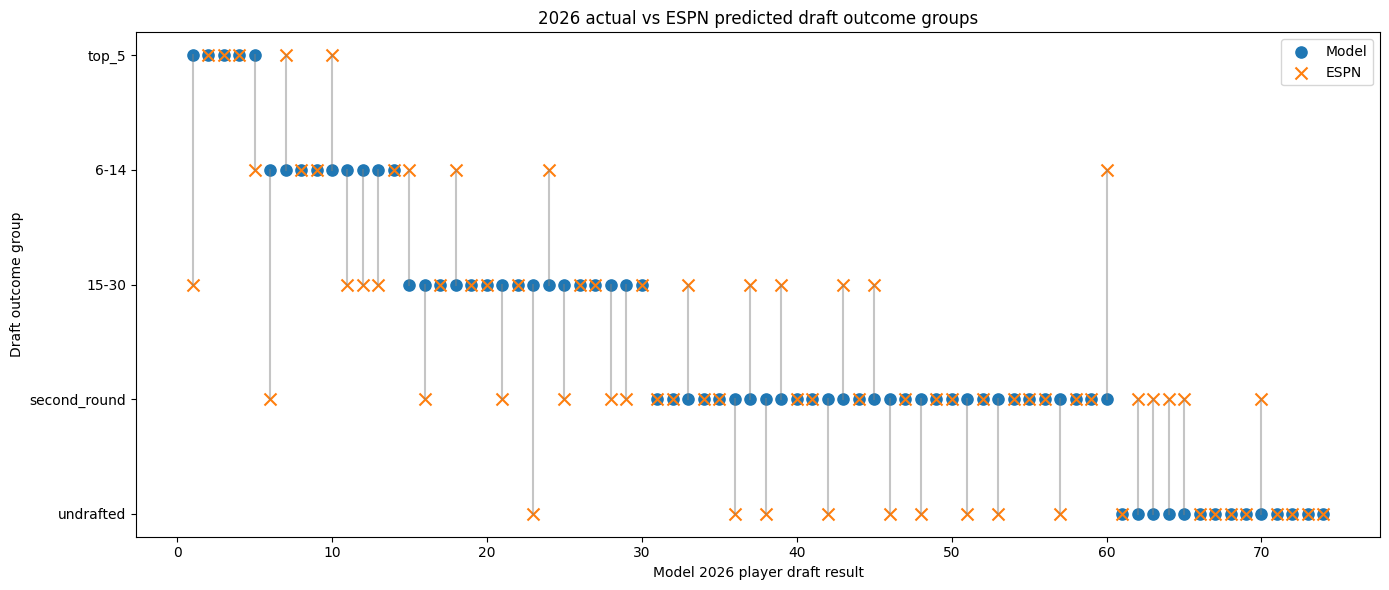

In [248]:
plot_2026_df = comparison_2026_df.copy()

plot_2026_df["model_rank_group"] = plot_2026_df["model_group"].map(group_to_rank)
plot_2026_df["espn_rank_group"] = plot_2026_df["espn_group"].map(group_to_rank)

plot_2026_df["abs_group_difference"] = (
    plot_2026_df["model_rank_group"] - plot_2026_df["espn_rank_group"]
).abs()

plot_2026_df["model_group_order"] = pd.Categorical(
    plot_2026_df["model_group"],
    categories=group_order,
    ordered=True
)
plot_2026_df = (
    plot_2026_df
    .sort_values(["model_group_order", "name"])
    .reset_index(drop=True)
)

plot_2026_df["player_order"] = range(1, len(plot_2026_df) + 1)
plt.figure(figsize=(14, 6))

for _, row in plot_2026_df.iterrows():
    if row["abs_group_difference"] > 0:
        plt.plot(
            [row["player_order"], row["player_order"]],
            [row["model_rank_group"], row["espn_rank_group"]],
            color="gray",
            alpha=0.45,
            linewidth=1.5
        )

plt.scatter(
    plot_2026_df["player_order"],
    plot_2026_df["model_rank_group"],
    label="Model",
    s=65
)
plt.scatter(
    plot_2026_df["player_order"],
    plot_2026_df["espn_rank_group"],
    marker="x",
    label="ESPN",
    s=75
)

plt.yticks(list(rank_to_label.keys()), list(rank_to_label.values()))
plt.gca().invert_yaxis()

plt.xlabel("Model 2026 player draft result")
plt.ylabel("Draft outcome group")
plt.title("2026 actual vs ESPN predicted draft outcome groups")

plt.legend()
plt.tight_layout()
plt.show()

Let's see which players differ the most between the two models:

In [250]:
largest_disagreements_2026 = (
    plot_2026_df[plot_2026_df["abs_group_difference"] >= 2]
    .sort_values(["abs_group_difference", "name"], ascending=[False, True])
    [[
        "name",
        "model_group",
        "espn_group",
        "abs_group_difference"
    ]]
)
largest_disagreements_2026

,name,model_group,espn_group,abs_group_difference
0,allen graves,top_5,picks_15_30,2
5,amari allen,picks_6_14,second_round,2
22,jacob cofie,picks_15_30,undrafted,2
59,yaxel lendeborg,second_round,picks_6_14,2


That's fun, previously mentioned Yaxel Lendeborg is one of the largest disagreements between the model draft board and the ESPN mock draft. The raw model classification assigns him to picks_6_14, but after applying draft-board constraints he falls to second_round.

This happens because his class probabilities are spread across several outcomes rather than concentrated in one group. The model detects lottery-level potential, but it is not confident enough to keep him inside the first round once players are ranked against the full 2026 prediction pool.

ESPN is much more optimistic about Lendeborg, placing him in the lottery range. This likely reflects contextual information that is not fully captured by the structured dataset.

As a result, the 2026 prediction should be interpreted as a prospective forecast rather than a true evaluation, because the real draft results are not yet available. The raw model output initially assigned too many players to the top_5 group, which reflects a limitation of independent classification: the model identifies top-5-like profiles but does not enforce draft slot constraints. After post-processing, the predictions were converted into a more realistic draft-board format. Compared with the ESPN mock draft, the model shows partial agreement. But ESPN is generally more informed by scouting context, team needs, combine performance, and draft buzz, while the model reflects only structured historical player data. 

### Evaluation Step 5 - Model deploy for the future comparison 

As an additional deployment idea, the 2026 predictions can be published as a small static dashboard. Before the real draft, the page would show the model draft-board prediction and its comparison with the ESPN mock draft. After the draft, a script can fetch the real 2026 draft results, merge them with the saved model and ESPN predictions, and automatically generate updated confusion matrices and visualizations.

This deployment does not require retraining the model. The saved 2026 prediction table is enough for post-draft evaluation. The model remains fixed, and only the actual draft results are added later. A GitHub Pages dashboard with a manually triggered GitHub Actions workflow would be sufficient for this purpose.

In [251]:
final_2026_board.to_csv(
    "data/final/final_2026_model_draft_board.csv",
    index=False
)

comparison_2026_df.to_csv(
    "data/final/comparison_2026_model_vs_espn.csv",
    index=False
)

espn_mock_2026.to_csv(
    "data/final/espn_mock_draft_2026.csv",
    index=False
)